In [1]:
import geopandas as gpd
import pandas as pd

basline_blocks = gpd.read_file('./data/blocks_agg.geojson')
basline_blocks.head()

,residential,business,recreation,industrial,transport,special,agriculture,land_use,share,is_living,...,count_supermarket,capacity_park,count_park,capacity_train_building,count_train_building,capacity_kindergarten,count_kindergarten,capacity_school,count_school,geometry
0,0.690207,0.211718,0.055976,0.0,0.042093,0.0,0.0,LandUse.RESIDENTIAL,0.690207,6.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,"POLYGON ((30.09367 59.55207, 30.09375 59.55215..."
1,0.970519,0.029484,0.000000,0.0,0.000000,0.0,0.0,LandUse.RESIDENTIAL,0.970519,13.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,650.0,1.0,"POLYGON ((30.09448 59.56164, 30.09448 59.56164..."
2,0.936589,0.010562,0.052849,0.0,0.000000,0.0,0.0,LandUse.RESIDENTIAL,0.936589,15.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,"POLYGON ((30.12546 59.58002, 30.12541 59.57998..."
3,0.121353,0.819171,0.059489,0.0,0.000000,0.0,0.0,LandUse.BUSINESS,0.819171,2.0,...,0.0,1200.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,"POLYGON ((30.12501 59.56588, 30.12497 59.56582..."
4,0.068737,0.931312,0.000000,0.0,0.000000,0.0,0.0,LandUse.BUSINESS,0.931312,2.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,"POLYGON ((30.1249 59.56574, 30.12497 59.56582,..."


# Вычисления **площади участка**

In [2]:
baseline_blocks_test = basline_blocks.copy().to_crs(3857)
basline_blocks["site_area"] = baseline_blocks_test.geometry.area
basline_blocks.head()

,residential,business,recreation,industrial,transport,special,agriculture,land_use,share,is_living,...,capacity_park,count_park,capacity_train_building,count_train_building,capacity_kindergarten,count_kindergarten,capacity_school,count_school,geometry,site_area
0,0.690207,0.211718,0.055976,0.0,0.042093,0.0,0.0,LandUse.RESIDENTIAL,0.690207,6.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,"POLYGON ((30.09367 59.55207, 30.09375 59.55215...",836277.821579
1,0.970519,0.029484,0.000000,0.0,0.000000,0.0,0.0,LandUse.RESIDENTIAL,0.970519,13.0,...,0.0,0.0,0.0,0.0,0.0,0.0,650.0,1.0,"POLYGON ((30.09448 59.56164, 30.09448 59.56164...",420144.041613
2,0.936589,0.010562,0.052849,0.0,0.000000,0.0,0.0,LandUse.RESIDENTIAL,0.936589,15.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,"POLYGON ((30.12546 59.58002, 30.12541 59.57998...",302985.560228
3,0.121353,0.819171,0.059489,0.0,0.000000,0.0,0.0,LandUse.BUSINESS,0.819171,2.0,...,1200.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,"POLYGON ((30.12501 59.56588, 30.12497 59.56582...",124546.982903
4,0.068737,0.931312,0.000000,0.0,0.000000,0.0,0.0,LandUse.BUSINESS,0.931312,2.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,"POLYGON ((30.1249 59.56574, 30.12497 59.56582,...",119574.990985


# Вычисления **связанности**

In [3]:
from blocksnet.analysis.network.accessibility import area_accessibility
matrix = pd.read_pickle('./data/matrix.pickle')

In [4]:
# переиндексируем матрицу, индекс == столбцы == 0..n-1
matrix = matrix.copy()
matrix.index = range(len(matrix))
matrix.columns = matrix.index

# приводим блоки к тем же меткам
basline_blocks = basline_blocks.reset_index(drop=True)

# проверяем, что размеры совпадают
assert len(matrix) == len(basline_blocks)

area_acc_df = area_accessibility(matrix, basline_blocks)
basline_blocks = basline_blocks.join(area_acc_df)
basline_blocks.head()

,residential,business,recreation,industrial,transport,special,agriculture,land_use,share,is_living,...,count_park,capacity_train_building,count_train_building,capacity_kindergarten,count_kindergarten,capacity_school,count_school,geometry,site_area,area_accessibility
0,0.690207,0.211718,0.055976,0.0,0.042093,0.0,0.0,LandUse.RESIDENTIAL,0.690207,6.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,"POLYGON ((30.09367 59.55207, 30.09375 59.55215...",836277.821579,10.063987
1,0.970519,0.029484,0.000000,0.0,0.000000,0.0,0.0,LandUse.RESIDENTIAL,0.970519,13.0,...,0.0,0.0,0.0,0.0,0.0,650.0,1.0,"POLYGON ((30.09448 59.56164, 30.09448 59.56164...",420144.041613,10.210398
2,0.936589,0.010562,0.052849,0.0,0.000000,0.0,0.0,LandUse.RESIDENTIAL,0.936589,15.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,"POLYGON ((30.12546 59.58002, 30.12541 59.57998...",302985.560228,8.669212
3,0.121353,0.819171,0.059489,0.0,0.000000,0.0,0.0,LandUse.BUSINESS,0.819171,2.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,"POLYGON ((30.12501 59.56588, 30.12497 59.56582...",124546.982903,7.467434
4,0.068737,0.931312,0.000000,0.0,0.000000,0.0,0.0,LandUse.BUSINESS,0.931312,2.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,"POLYGON ((30.1249 59.56574, 30.12497 59.56582,...",119574.990985,8.285434


# Вычисления **показателей застройки**

In [5]:
from blocksnet.analysis.indicators import calculate_density_indicators 

blocks_df = calculate_density_indicators(basline_blocks[[
    'site_area',
    'footprint_area',
    'build_floor_area',
    'living_area'
]])
blocks_df.head()

2025-12-12 19:57:56.808 | WARNING  | blocksnet.analysis.indicators.density.schemas:_before_validate:19 - The non_living_area is not in columns, restoring


,site_area,footprint_area,build_floor_area,living_area,non_living_area,fsi,gsi,mxi,l,osr,share_living,share_non_living
0,836277.821579,7383.849525,10126.647386,930.718518,9195.928868,0.012109,0.008829,0.091908,1.371459,81.852753,0.126048,1.245411
1,420144.041613,15304.958732,89136.104333,63508.757346,25627.346987,0.212156,0.036428,0.712492,5.824002,4.541808,4.149554,1.674447
2,302985.560228,17141.628200,91971.715857,72292.449720,19679.266138,0.303551,0.056576,0.786029,5.365401,3.107955,4.217362,1.148039
3,124546.982903,9453.530183,21635.756605,4286.353971,17349.402634,0.173716,0.075903,0.198114,2.288643,5.319595,0.453413,1.835230
4,119574.990985,8567.309559,18736.950831,1791.211457,16945.739375,0.156696,0.071648,0.095598,2.187029,5.924533,0.209075,1.977953


In [6]:
basline_blocks.loc[:, blocks_df.columns] = blocks_df
basline_blocks.head()

,residential,business,recreation,industrial,transport,special,agriculture,land_use,share,is_living,...,geometry,site_area,area_accessibility,fsi,gsi,mxi,l,osr,share_living,share_non_living
0,0.690207,0.211718,0.055976,0.0,0.042093,0.0,0.0,LandUse.RESIDENTIAL,0.690207,6.0,...,"POLYGON ((30.09367 59.55207, 30.09375 59.55215...",836277.821579,10.063987,0.012109,0.008829,0.091908,1.371459,81.852753,0.126048,1.245411
1,0.970519,0.029484,0.000000,0.0,0.000000,0.0,0.0,LandUse.RESIDENTIAL,0.970519,13.0,...,"POLYGON ((30.09448 59.56164, 30.09448 59.56164...",420144.041613,10.210398,0.212156,0.036428,0.712492,5.824002,4.541808,4.149554,1.674447
2,0.936589,0.010562,0.052849,0.0,0.000000,0.0,0.0,LandUse.RESIDENTIAL,0.936589,15.0,...,"POLYGON ((30.12546 59.58002, 30.12541 59.57998...",302985.560228,8.669212,0.303551,0.056576,0.786029,5.365401,3.107955,4.217362,1.148039
3,0.121353,0.819171,0.059489,0.0,0.000000,0.0,0.0,LandUse.BUSINESS,0.819171,2.0,...,"POLYGON ((30.12501 59.56588, 30.12497 59.56582...",124546.982903,7.467434,0.173716,0.075903,0.198114,2.288643,5.319595,0.453413,1.835230
4,0.068737,0.931312,0.000000,0.0,0.000000,0.0,0.0,LandUse.BUSINESS,0.931312,2.0,...,"POLYGON ((30.1249 59.56574, 30.12497 59.56582,...",119574.990985,8.285434,0.156696,0.071648,0.095598,2.187029,5.924533,0.209075,1.977953


# Вычисления **морфотипов застройки**

In [7]:
from blocksnet.analysis.morphotypes import get_strelka_morphotypes


blocks_df = get_strelka_morphotypes(basline_blocks)
basline_blocks.loc[:, blocks_df.columns] = blocks_df
basline_blocks.head()

,residential,business,recreation,industrial,transport,special,agriculture,land_use,share,is_living,...,site_area,area_accessibility,fsi,gsi,mxi,l,osr,share_living,share_non_living,morphotype
0,0.690207,0.211718,0.055976,0.0,0.042093,0.0,0.0,LandUse.RESIDENTIAL,0.690207,6.0,...,836277.821579,10.063987,0.012109,0.008829,0.091908,1.371459,81.852753,0.126048,1.245411,individual residential
1,0.970519,0.029484,0.000000,0.0,0.000000,0.0,0.0,LandUse.RESIDENTIAL,0.970519,13.0,...,420144.041613,10.210398,0.212156,0.036428,0.712492,5.824002,4.541808,4.149554,1.674447,mid-rise
2,0.936589,0.010562,0.052849,0.0,0.000000,0.0,0.0,LandUse.RESIDENTIAL,0.936589,15.0,...,302985.560228,8.669212,0.303551,0.056576,0.786029,5.365401,3.107955,4.217362,1.148039,mid-rise
3,0.121353,0.819171,0.059489,0.0,0.000000,0.0,0.0,LandUse.BUSINESS,0.819171,2.0,...,124546.982903,7.467434,0.173716,0.075903,0.198114,2.288643,5.319595,0.453413,1.835230,low-rise model
4,0.068737,0.931312,0.000000,0.0,0.000000,0.0,0.0,LandUse.BUSINESS,0.931312,2.0,...,119574.990985,8.285434,0.156696,0.071648,0.095598,2.187029,5.924533,0.209075,1.977953,low-rise model


# Выбор **проктной территории**

# Финальный набор данных

In [8]:
cols = [
    'residential','business','recreation','industrial','transport','special',
    'agriculture','land_use','share','footprint_area','build_floor_area',
    'living_area','non_living_area','population','site_area','fsi','gsi',
    'mxi','l','morphotype','area_accessibility', 'geometry'
]
basline_blocks = basline_blocks[cols]
basline_blocks.head()

,residential,business,recreation,industrial,transport,special,agriculture,land_use,share,footprint_area,...,non_living_area,population,site_area,fsi,gsi,mxi,l,morphotype,area_accessibility,geometry
0,0.690207,0.211718,0.055976,0.0,0.042093,0.0,0.0,LandUse.RESIDENTIAL,0.690207,7383.849525,...,9195.928868,30.0,836277.821579,0.012109,0.008829,0.091908,1.371459,individual residential,10.063987,"POLYGON ((30.09367 59.55207, 30.09375 59.55215..."
1,0.970519,0.029484,0.000000,0.0,0.000000,0.0,0.0,LandUse.RESIDENTIAL,0.970519,15304.958732,...,25627.346987,2000.0,420144.041613,0.212156,0.036428,0.712492,5.824002,mid-rise,10.210398,"POLYGON ((30.09448 59.56164, 30.09448 59.56164..."
2,0.936589,0.010562,0.052849,0.0,0.000000,0.0,0.0,LandUse.RESIDENTIAL,0.936589,17141.628200,...,19679.266138,2275.0,302985.560228,0.303551,0.056576,0.786029,5.365401,mid-rise,8.669212,"POLYGON ((30.12546 59.58002, 30.12541 59.57998..."
3,0.121353,0.819171,0.059489,0.0,0.000000,0.0,0.0,LandUse.BUSINESS,0.819171,9453.530183,...,17349.402634,134.0,124546.982903,0.173716,0.075903,0.198114,2.288643,low-rise model,7.467434,"POLYGON ((30.12501 59.56588, 30.12497 59.56582..."
4,0.068737,0.931312,0.000000,0.0,0.000000,0.0,0.0,LandUse.BUSINESS,0.931312,8567.309559,...,16945.739375,56.0,119574.990985,0.156696,0.071648,0.095598,2.187029,low-rise model,8.285434,"POLYGON ((30.1249 59.56574, 30.12497 59.56582,..."


In [9]:
from catboost import CatBoostRegressor

from urbanomy.methods.land_value_modeling import LandPriceEstimator

model = CatBoostRegressor()
model.load_model('./data/catboost_model.cbm')  # модель на лог-цене

estimator = LandPriceEstimator(
    model=model,
    blocks=basline_blocks, #or blocks_198
)
blocks_pred = estimator.predict()
blocks_pred.head()


,residential,business,recreation,industrial,transport,special,agriculture,land_use,share,footprint_area,...,population,site_area,fsi,gsi,mxi,l,morphotype,area_accessibility,geometry,land_value
0,0.690207,0.211718,0.055976,0.0,0.042093,0.0,0.0,LandUse.RESIDENTIAL,0.690207,7383.849525,...,30.0,836277.821579,0.012109,0.008829,0.091908,1.371459,individual residential,10.063987,"POLYGON ((30.09367 59.55207, 30.09375 59.55215...",6.833466e+08
1,0.970519,0.029484,0.000000,0.0,0.000000,0.0,0.0,LandUse.RESIDENTIAL,0.970519,15304.958732,...,2000.0,420144.041613,0.212156,0.036428,0.712492,5.824002,mid-rise,10.210398,"POLYGON ((30.09448 59.56164, 30.09448 59.56164...",8.727378e+08
2,0.936589,0.010562,0.052849,0.0,0.000000,0.0,0.0,LandUse.RESIDENTIAL,0.936589,17141.628200,...,2275.0,302985.560228,0.303551,0.056576,0.786029,5.365401,mid-rise,8.669212,"POLYGON ((30.12546 59.58002, 30.12541 59.57998...",6.121753e+08
3,0.121353,0.819171,0.059489,0.0,0.000000,0.0,0.0,LandUse.BUSINESS,0.819171,9453.530183,...,134.0,124546.982903,0.173716,0.075903,0.198114,2.288643,low-rise model,7.467434,"POLYGON ((30.12501 59.56588, 30.12497 59.56582...",1.809802e+08
4,0.068737,0.931312,0.000000,0.0,0.000000,0.0,0.0,LandUse.BUSINESS,0.931312,8567.309559,...,56.0,119574.990985,0.156696,0.071648,0.095598,2.187029,low-rise model,8.285434,"POLYGON ((30.1249 59.56574, 30.12497 59.56582,...",1.709968e+08


count       347.000000
mean     134532.459241
std       73884.256473
min           0.000000
25%       64773.223914
50%      149911.559259
75%      200799.237991
max      259942.812036
Name: land_value_per_100m2, dtype: float64


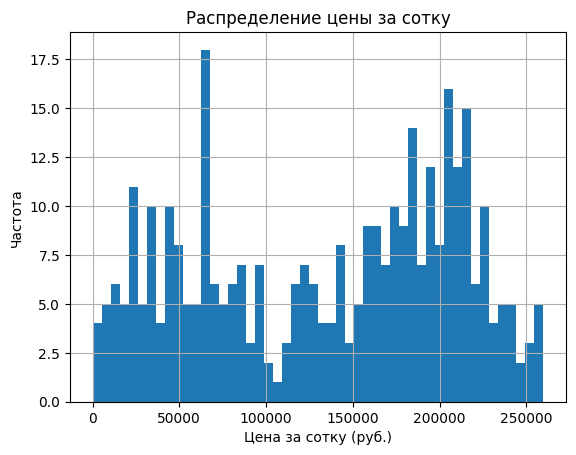

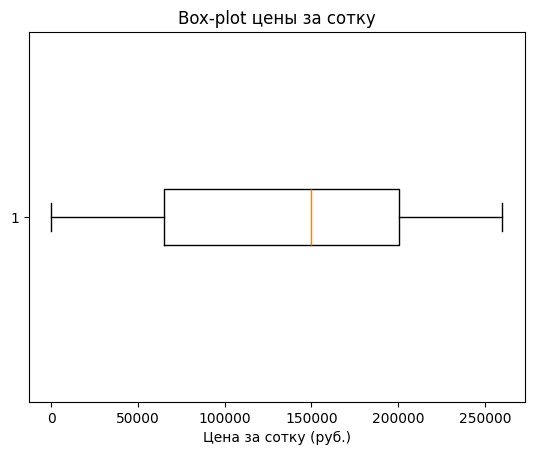

In [57]:
import numpy as np
import matplotlib.pyplot as plt
# 1) Цена за сотку (100 м²)
blocks_pred["land_value_per_100m2"] = blocks_pred["land_value"] / blocks_pred["site_area"] * 100

# 2) Заменяем inf на NaN
blocks_pred = blocks_pred.replace([np.inf, -np.inf], np.nan)
blocks_pred = blocks_pred.fillna(0)

# 3) Удаляем выбросы: оставляем данные до 99-го перцентиля
p99 = blocks_pred["land_value_per_100m2"].quantile(0.99)
blocks_clean = blocks_pred[blocks_pred["land_value_per_100m2"] <= p99].copy()

print(blocks_clean["land_value_per_100m2"].describe())

# 4) Гистограмма после очистки
plt.figure()
blocks_clean["land_value_per_100m2"].dropna().hist(bins=50)
plt.xlabel("Цена за сотку (руб.)")
plt.ylabel("Частота")
plt.title("Распределение цены за сотку")
plt.show()

# 5) Box-plot после очистки
plt.figure()
plt.boxplot(blocks_clean["land_value_per_100m2"].dropna(), vert=False)
plt.xlabel("Цена за сотку (руб.)")
plt.title("Box-plot цены за сотку")
plt.show()


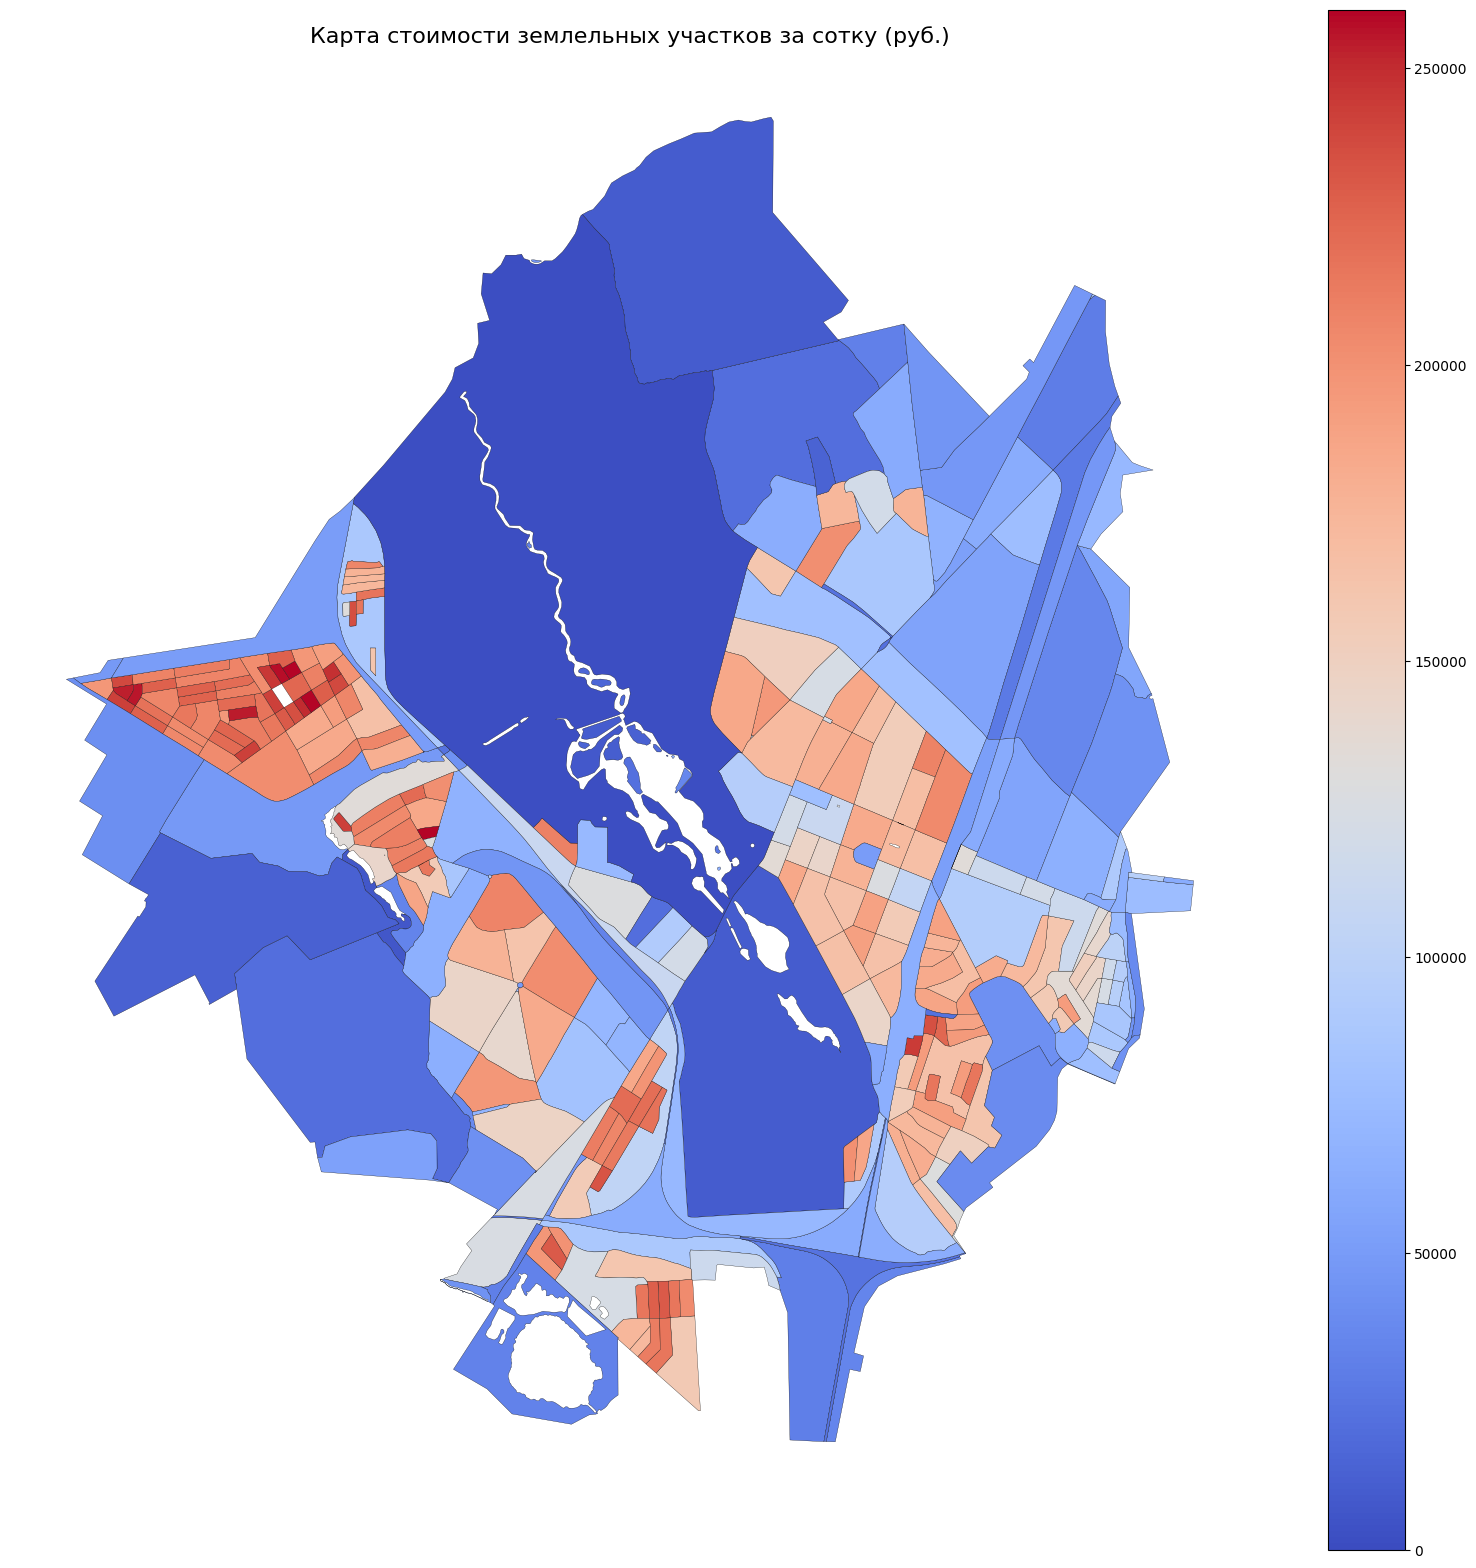

In [51]:
import matplotlib.pyplot as plt

blocks_clean.plot(
    column='land_value_per_100m2',
    legend=True,
    figsize=(20,20),
    cmap='coolwarm',
    edgecolor='black',   # <-- цвет границы
    linewidth=0.2        # <-- толщина границы
).set_axis_off()
plt.title('Карта стоимости землельных участков за сотку (руб.)', fontsize=16)

plt.show()

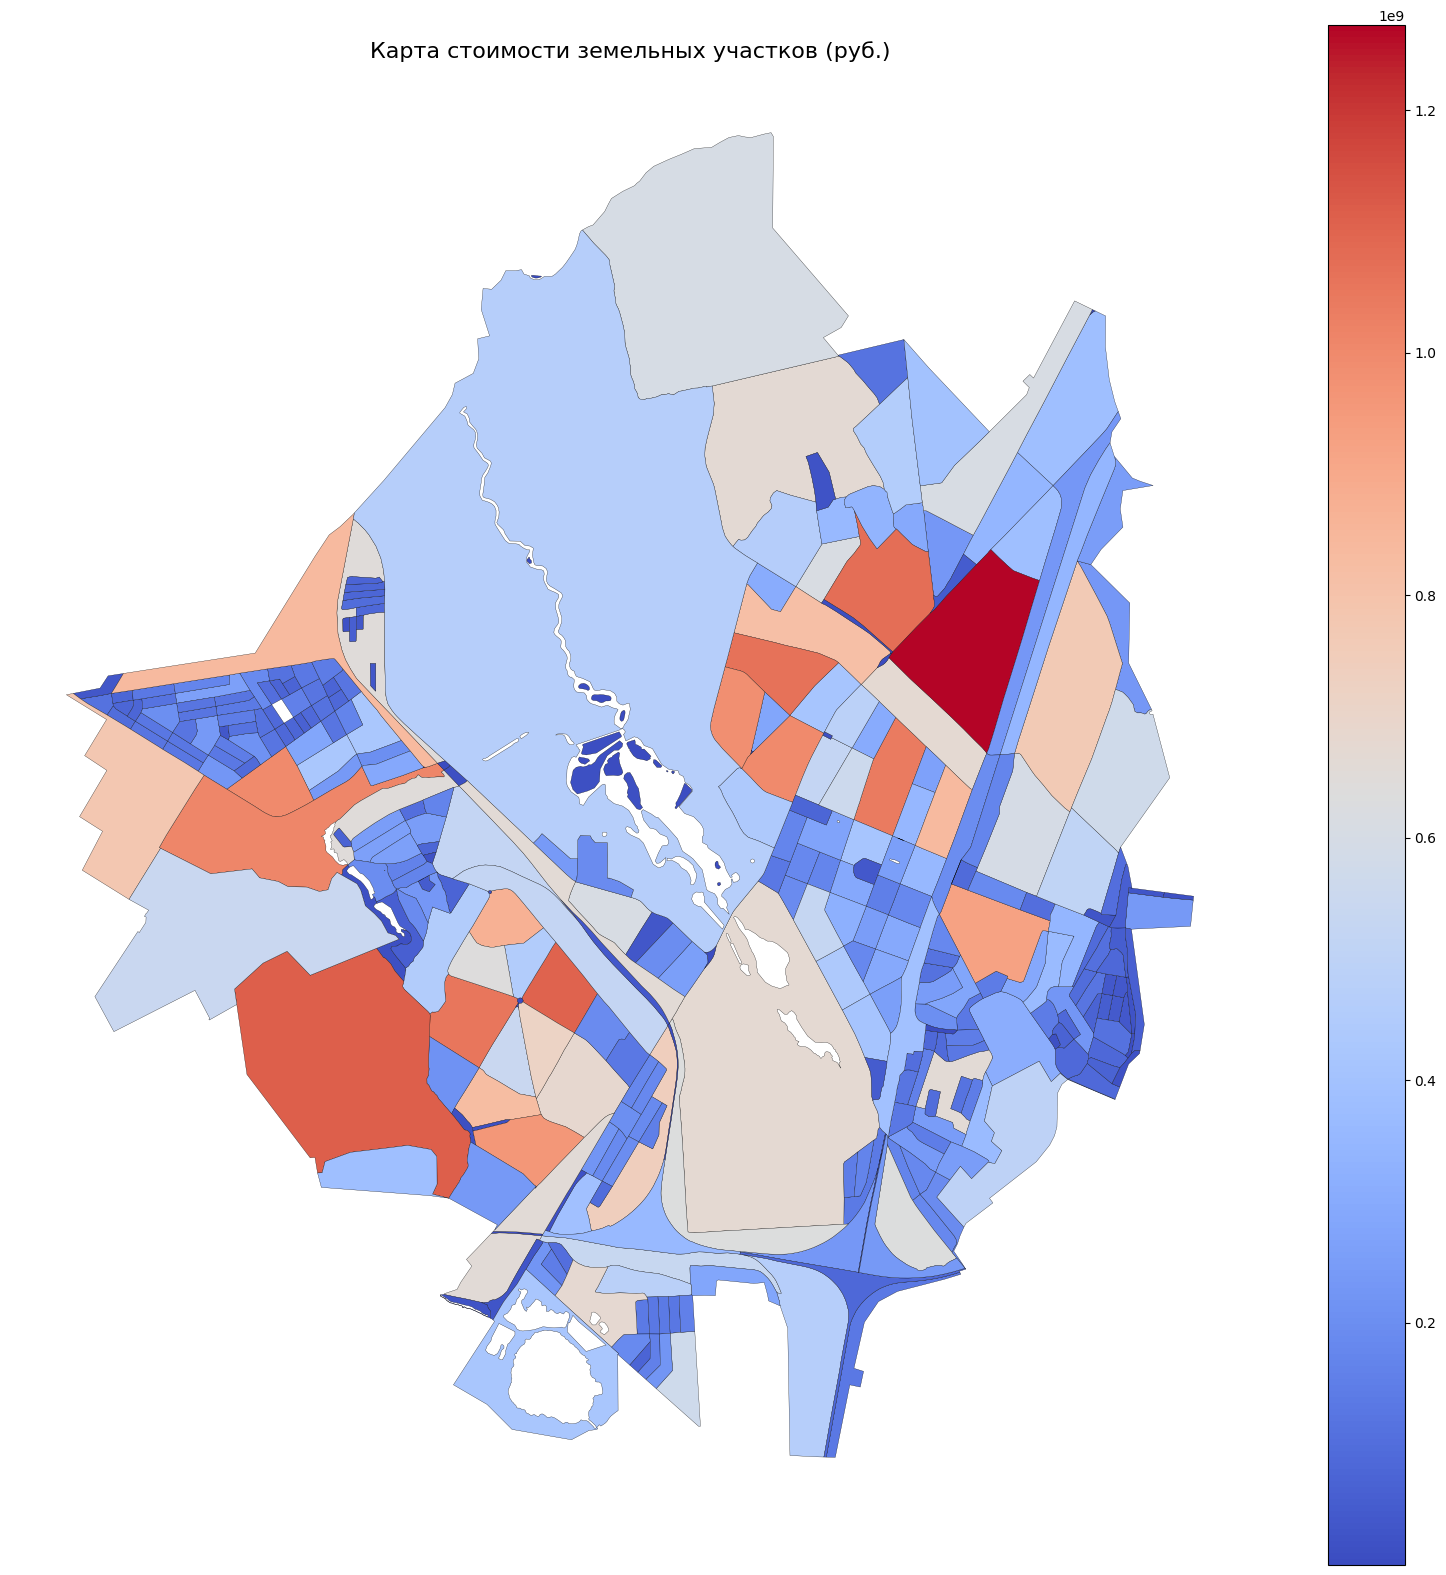

In [52]:
import matplotlib.pyplot as plt

blocks_clean.plot(
    column='land_value',
    legend=True,
    figsize=(20,20),
    cmap='coolwarm',
    edgecolor='black',   # <-- цвет границы
    linewidth=0.2        # <-- толщина границы
).set_axis_off()
plt.title('Карта стоимости земельных участков (руб.)', fontsize=16)

plt.show()

In [13]:
# blocks_clean.to_file('./data/test/gatchina_baseline.geojson', driver='GeoJSON')

In [14]:
# blocks_clean.explore()

# **Cценарии развития**

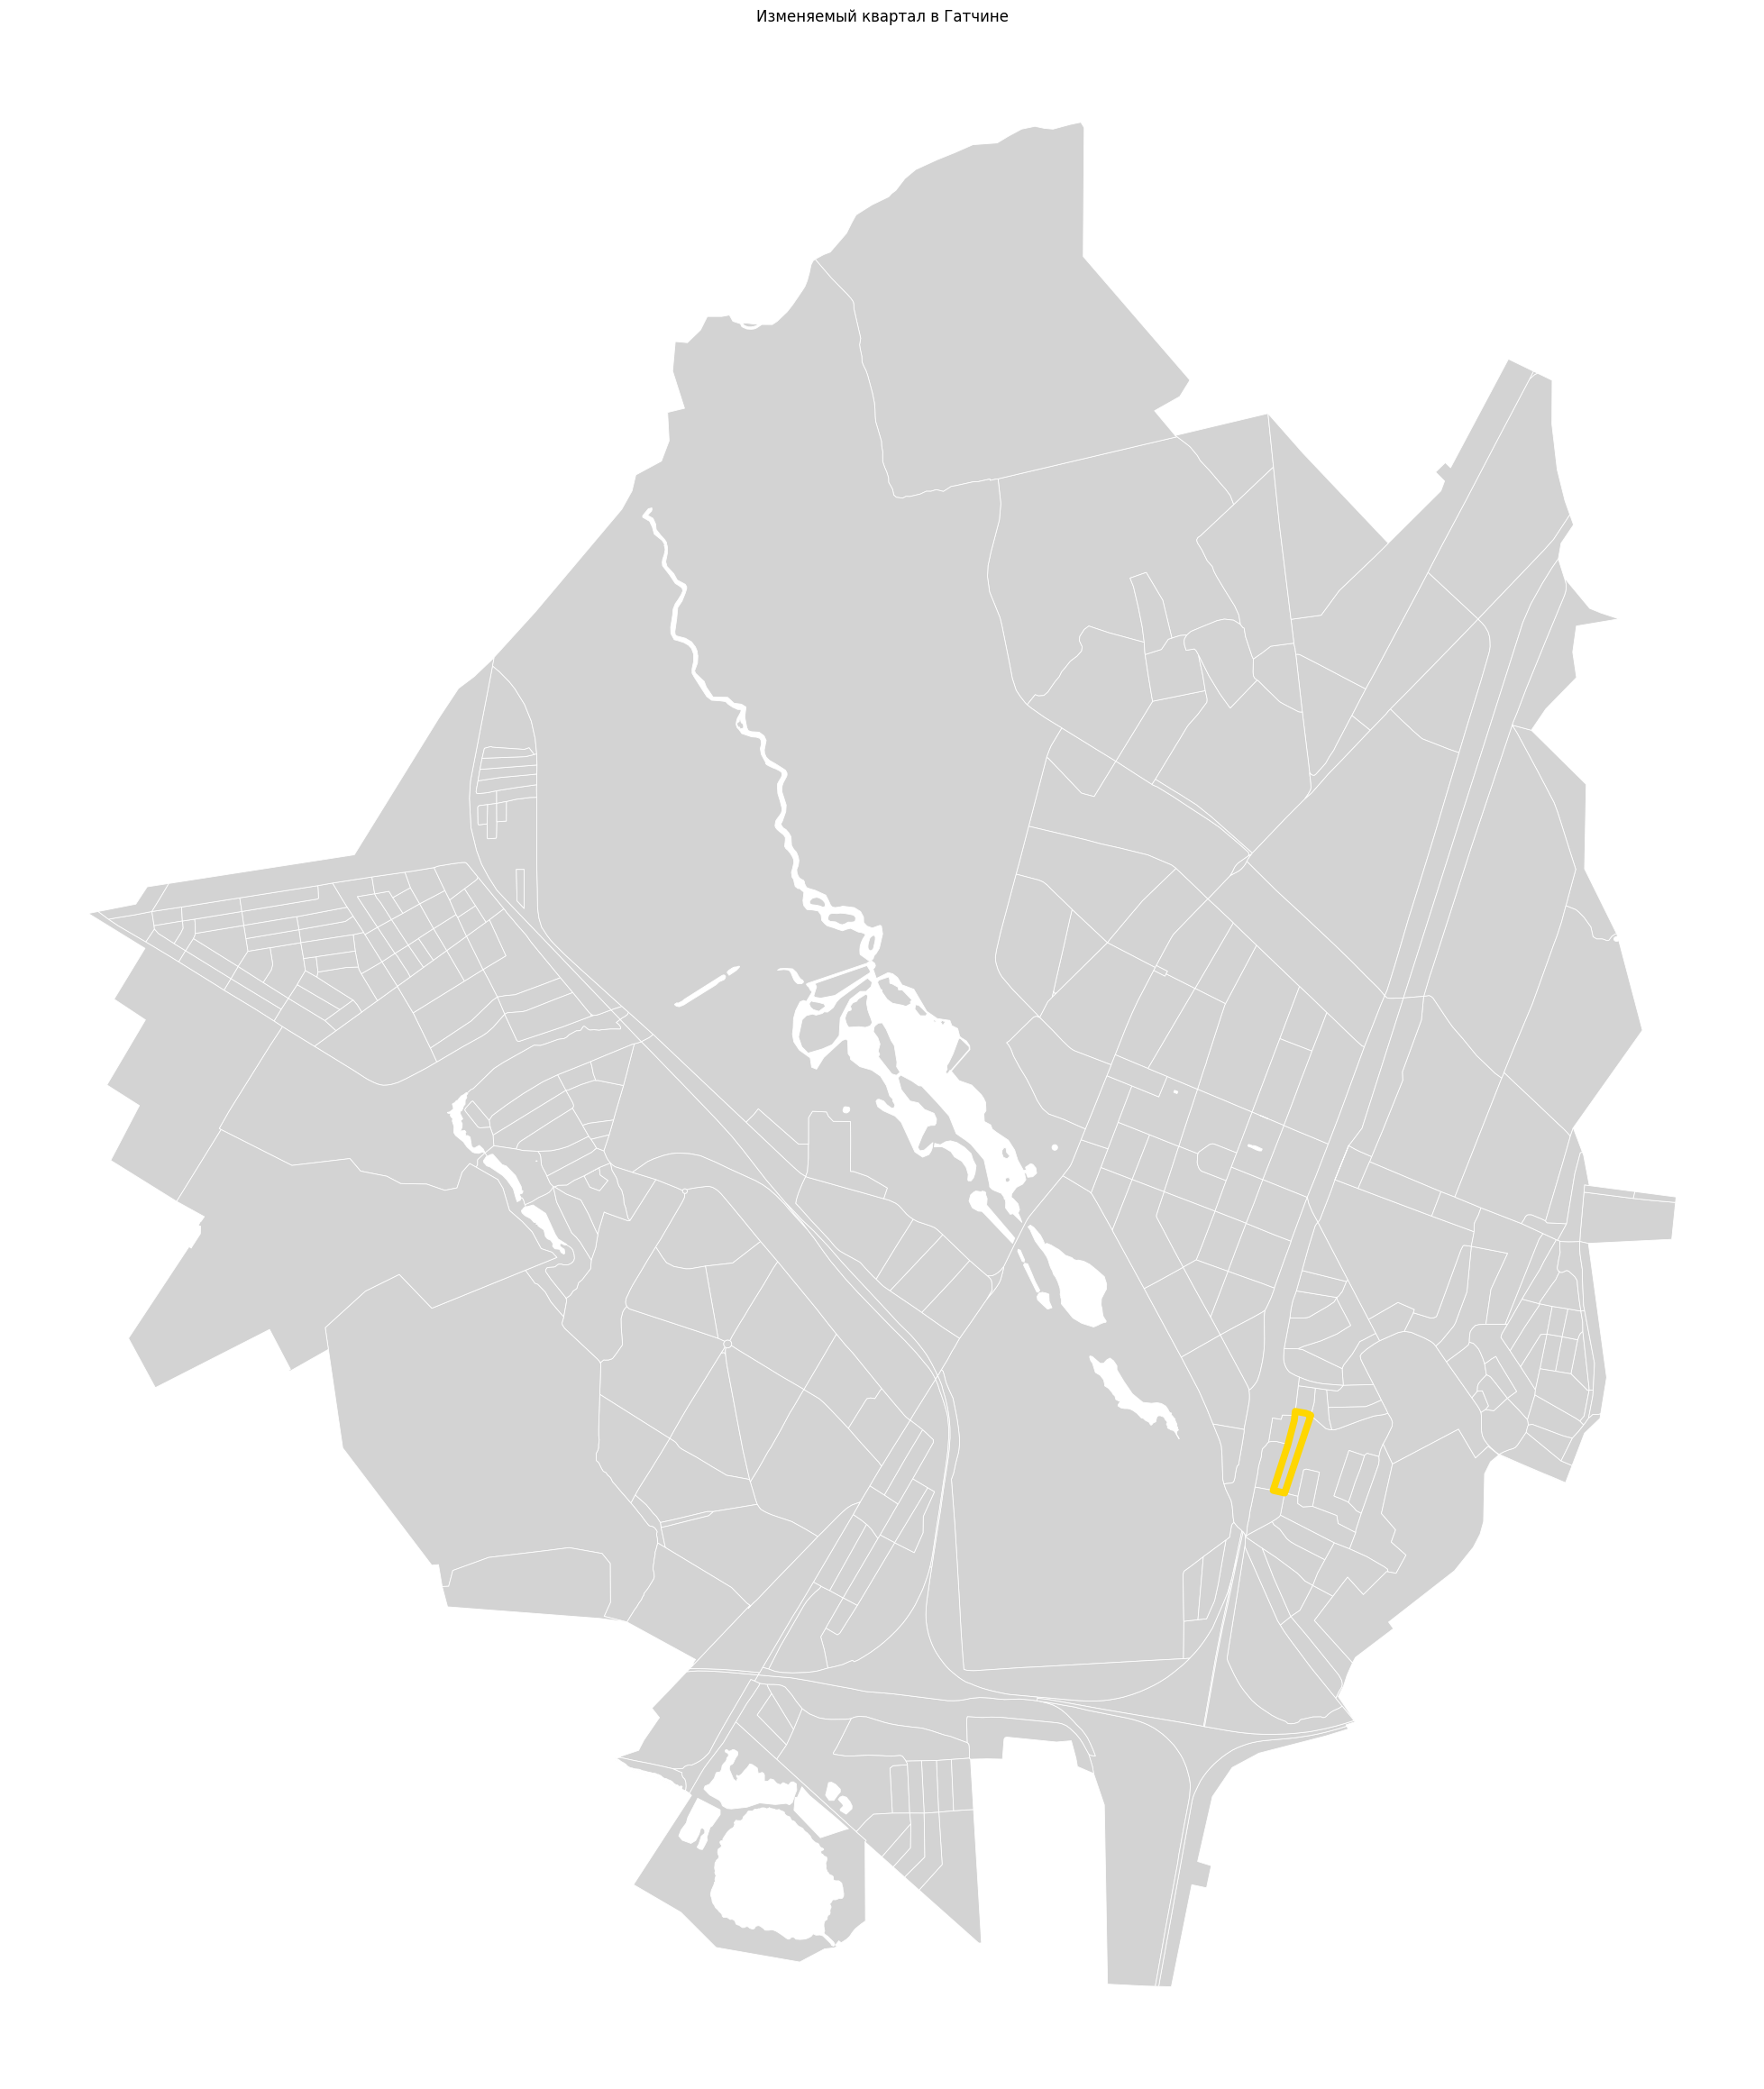

In [15]:
import matplotlib.pyplot as plt
basline_blocks["id"] = basline_blocks.index

fig, ax = plt.subplots(figsize=(25, 35))
basline_blocks.plot(ax=ax, color="lightgrey", edgecolor="white", linewidth=0.6)  # фон
basline_blocks.loc[basline_blocks["id"]==143].plot(
    ax=ax, color="none", edgecolor="gold", linewidth=5.5
)
ax.set_title("Изменяемый квартал в Гатчине")
ax.axis("off")
plt.show()

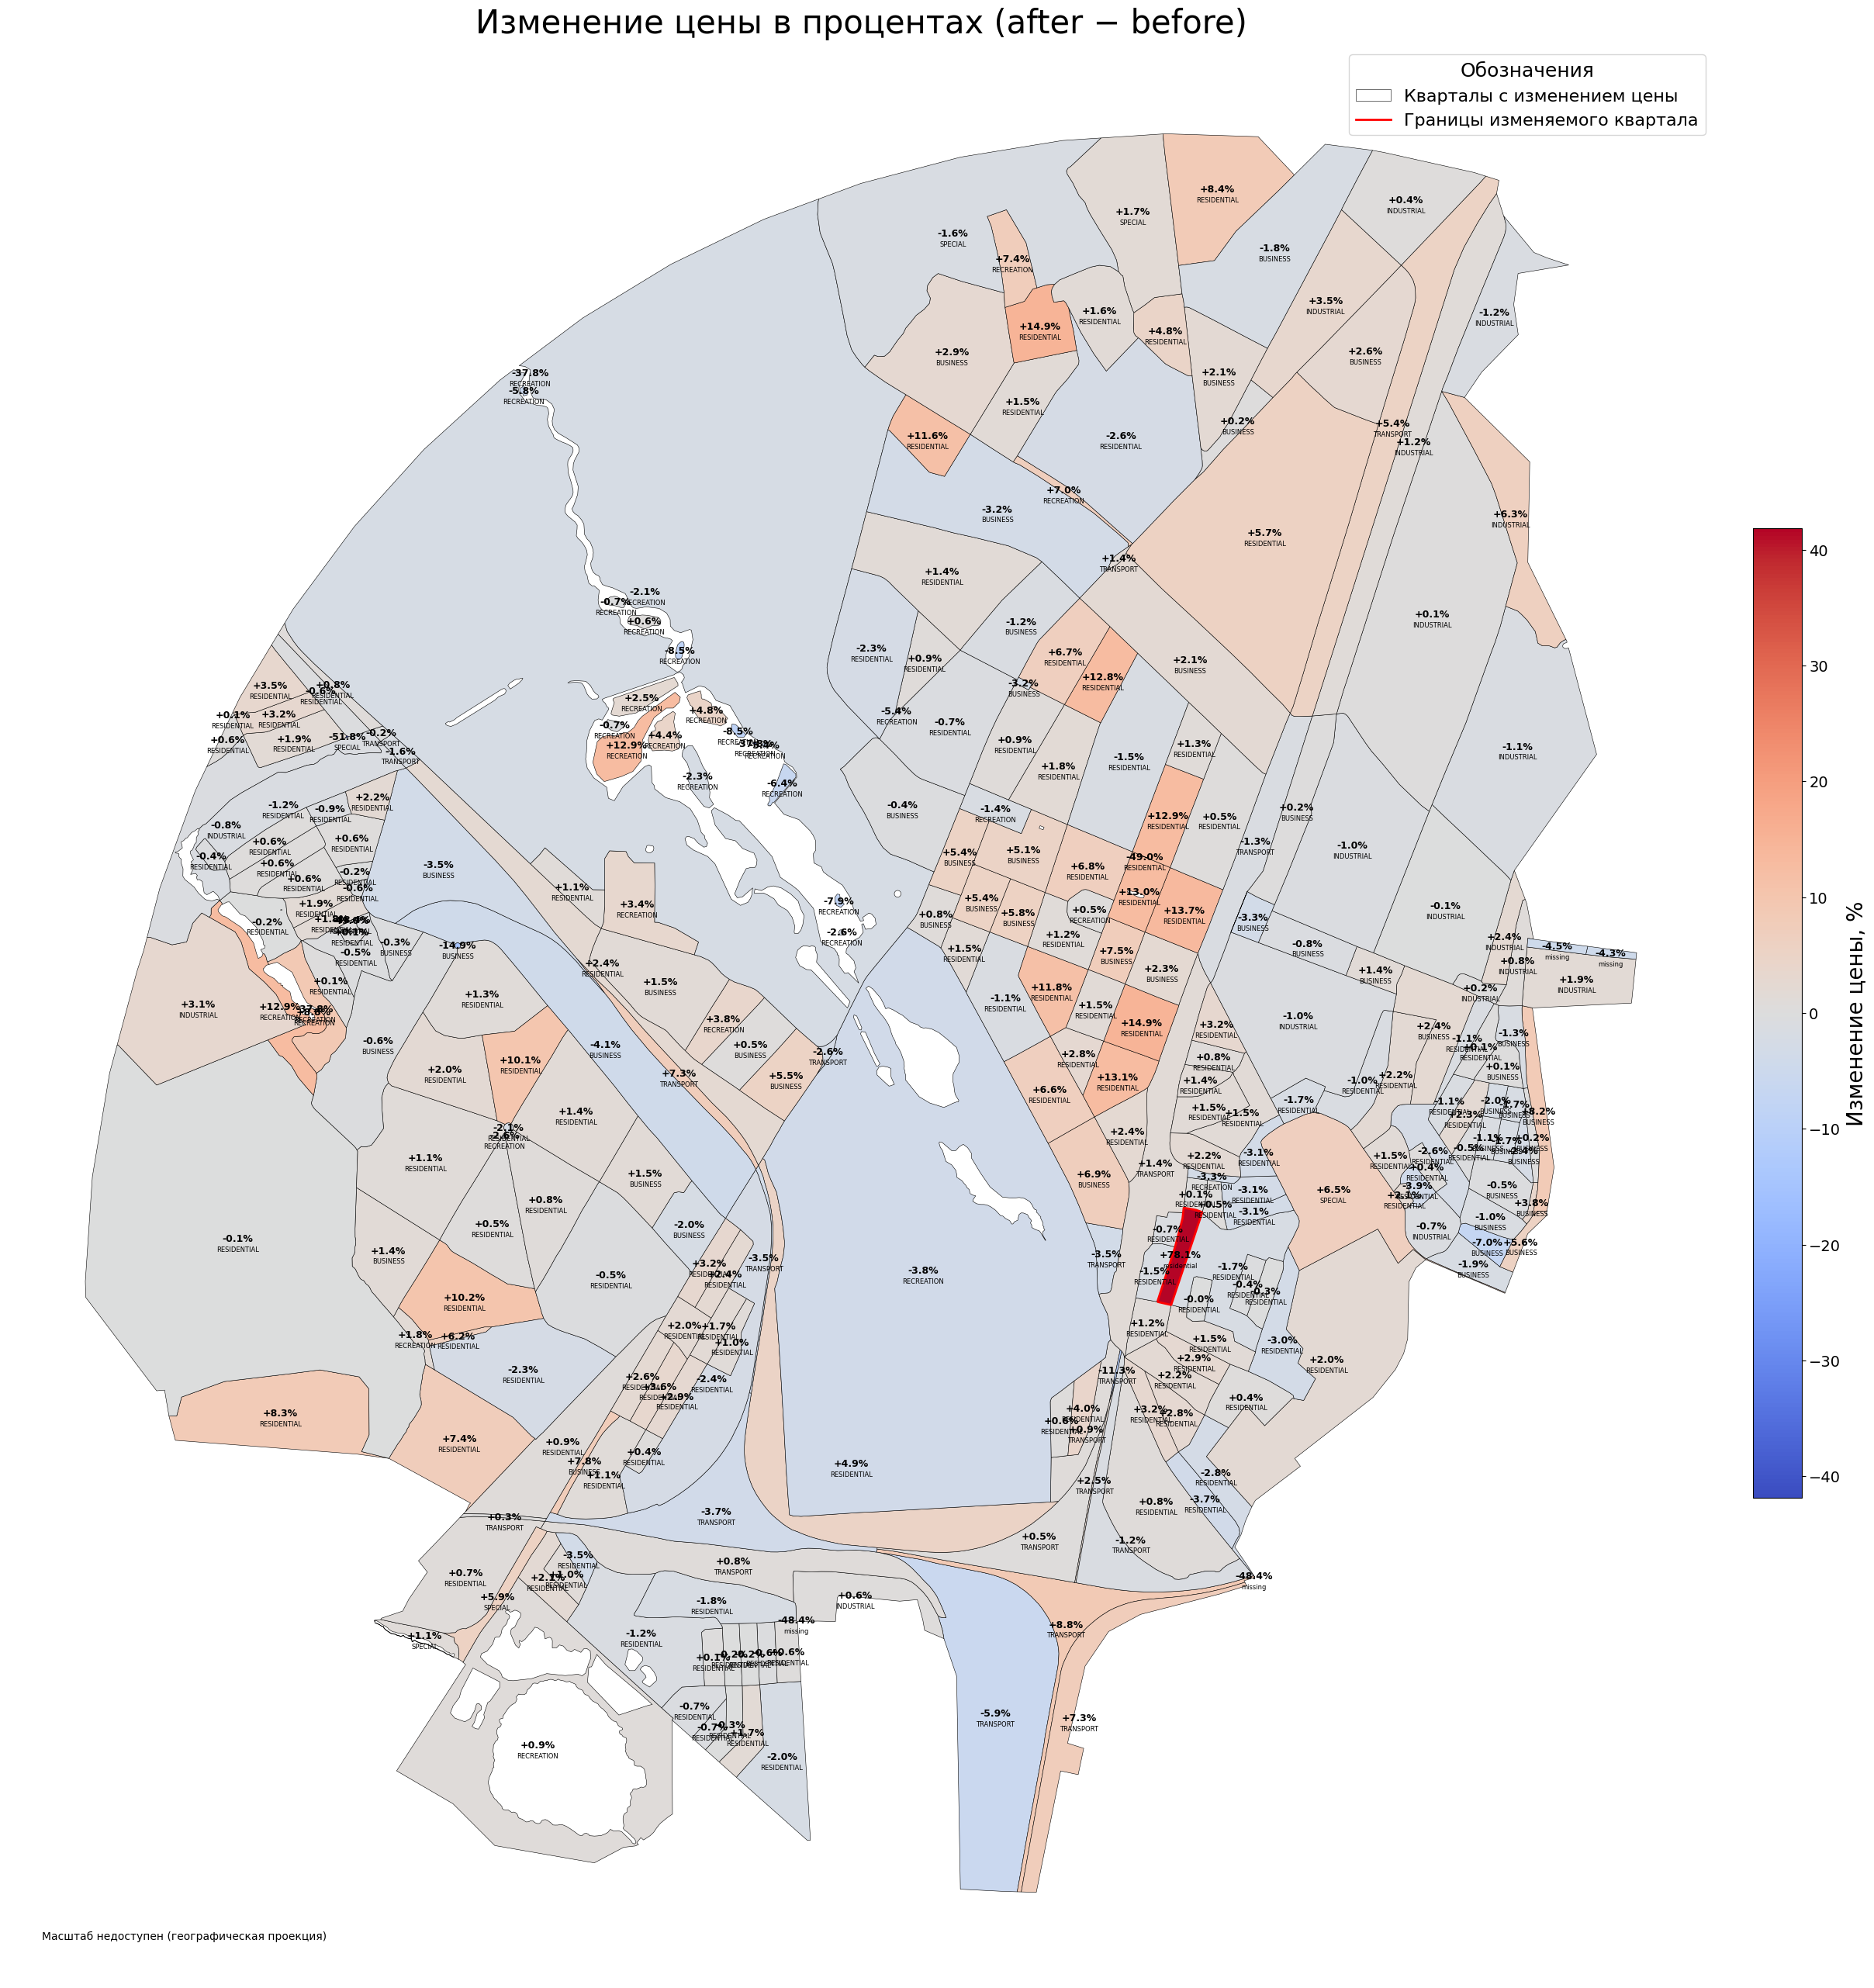


Статистика по кварталам в контексте (|Δ₽| > 1e-09):

Изменяемый квартал:
index | land_use | до (₽) → после (₽) | Δ₽ | Δ%
143 | residential | 155 153 751 ₽ → 276 377 532 ₽ | +121 223 781 ₽ | +78.1%

Кварталы в границах проекта:
Нет кварталов проекта с изменениями выше порога.

Кварталы в контексте:
index | land_use | до (₽) → после (₽) | Δ₽ | Δ%
311 | RESIDENTIAL | 568 220 429 ₽ → 556 842 678 ₽ | -11 377 751 ₽ | -2.0%
248 | TRANSPORT | 470 108 239 ₽ → 442 529 069 ₽ | -27 579 170 ₽ | -5.9%
298 | TRANSPORT | 83 519 164 ₽ → 90 870 660 ₽ | +7 351 496 ₽ | +8.8%
115 | RESIDENTIAL | 127 433 496 ₽ → 126 651 313 ₽ | -782 183 ₽ | -0.6%
317 | RESIDENTIAL | 155 658 890 ₽ → 156 531 243 ₽ | +872 354 ₽ | +0.6%
312 | missing | 14 703 ₽ → 7 586 ₽ | -7 117 ₽ | -48.4%
318 | INDUSTRIAL | 279 176 632 ₽ → 280 769 122 ₽ | +1 592 490 ₽ | +0.6%
225 | TRANSPORT | 231 854 941 ₽ → 233 001 445 ₽ | +1 146 505 ₽ | +0.5%
299 | TRANSPORT | 3 524 255 ₽ → 3 611 015 ₽ | +86 759 ₽ | +2.5%
5 | TRANSPORT | 134 048 439 ₽ → 1

In [ ]:
from urbanomy.methods.land_value_modeling import (
    ScenarioTEPModifier,
    plot_scenario_impact,
    transfer_baseline_prices,
)

blocks_before = basline_blocks.copy()

changes = {
    # Структура использования территории
    "land_use": "LandUse.RESIDENTIAL",
    "residential": 1.0,
    "business": 0.0,
    "recreation": 0.0,
    "industrial": 0.0,
    "transport": 0.0,
    "special": 0.0,
    "agriculture": 0.0,
    "share": 1.0,

    "footprint_area": 48170.0451624,    # ≈ 60% от site_area
    "build_floor_area": 481700.451624,  # FSI ≈ 6.0
    "living_area": 337190.3161368,      # ≈ 70% 
    "non_living_area": 144510.1354872,  # ≈ 30% 
    "population": 5537,                # 


    "fsi": 6.0,                         # build_floor_area / site_area
    "gsi": 0.60,                        # footprint_area / site_area
    "l": 10.0,                          # build_floor_area / footprint_area (этажность)
                    # build_floor_area / footprint_area (этажность)

    # Морфотип – высотный дом
    "morphotype": "high-rise residential",
    }

target_idx = 143

modifier = ScenarioTEPModifier(blocks_before)
blocks_after = modifier.apply(target_idx, changes)

# 1) Предсказание стоимости до/после
before_estimator = LandPriceEstimator(model=model, blocks=blocks_before)
after_estimator = LandPriceEstimator(model=model, blocks=blocks_after)

blocks_before_pred = before_estimator.predict()
blocks_before_pred["land_value_per_100m2"] = blocks_before_pred["land_value"] / blocks_before_pred["site_area"] * 100

blocks_after_pred = after_estimator.predict()
blocks_after_pred["land_value_per_100m2"] = blocks_after_pred["land_value"] / blocks_after_pred["site_area"] * 100

blocks_full_value = transfer_baseline_prices(
    after_blocks=blocks_after_pred,
    before_blocks=blocks_before_pred,
    scenario_mode=False,
)

blocks_full_value = blocks_full_value.replace([np.inf, -np.inf], np.nan)
blocks_full_value = blocks_full_value.fillna(0)

# 3) Только визуализация и статистика по процентным изменениям
scenario_result = plot_scenario_impact(
    blocks=blocks_full_value,
    target_idx=target_idx,          
    target_id_column="id",   # если колонка называется иначе — укажи здесь
    figsize=(25, 35),
)

In [ ]:
# cols = [
#     "land_use",
#     "land_value",
#     "land_value_per_100m2",
#     "land_value_before",
#     "land_value_before_per_100m2",
#     "land_value_delta_pct",
#     blocks_full_value.geometry.name,  # обычно "geometry"
# ]
# blocks_full_value  = blocks_full_value.fillna(0)
# blocks_full_value = blocks_full_value[cols]
# blocks_full_value

,land_use,land_value,land_value_per_100m2,land_value_before,land_value_before_per_100m2,land_value_delta_pct,geometry
0,LandUse.RESIDENTIAL,6.800212e+08,81315.230092,6.833466e+08,81712.868330,-0.486629,"POLYGON ((30.09367 59.55207, 30.09375 59.55215..."
1,LandUse.RESIDENTIAL,8.837095e+08,210334.879630,8.727378e+08,207723.484640,1.257150,"POLYGON ((30.09448 59.56164, 30.09448 59.56164..."
2,LandUse.RESIDENTIAL,6.212153e+08,205031.337014,6.121753e+08,202047.687390,1.476706,"POLYGON ((30.12546 59.58002, 30.12541 59.57998..."
3,LandUse.BUSINESS,1.907719e+08,153172.669748,1.809802e+08,145310.813724,5.410372,"POLYGON ((30.12501 59.56588, 30.12497 59.56582..."
4,LandUse.BUSINESS,1.808311e+08,151228.191805,1.709968e+08,143003.845249,5.751137,"POLYGON ((30.1249 59.56574, 30.12497 59.56582,..."
...,...,...,...,...,...,...,...
346,LandUse.SPECIAL,4.669422e+08,62111.114542,4.589715e+08,61050.872974,1.736653,"POLYGON ((30.13472 59.59243, 30.13519 59.59012..."
347,LandUse.RESIDENTIAL,4.329091e+08,48599.747546,3.994135e+08,44839.421337,8.386206,"POLYGON ((30.13429 59.59456, 30.13472 59.59243..."
348,LandUse.RESIDENTIAL,4.159187e+08,58457.252900,3.841310e+08,53989.504887,8.275216,"POLYGON ((30.06949 59.54791, 30.06991 59.54711..."
349,LandUse.RESIDENTIAL,2.548863e+08,44852.414595,2.374099e+08,41777.086873,7.361279,"POLYGON ((30.084 59.5465, 30.08427 59.54673, 3..."


In [27]:
# blocks_full_value.to_file('./data/test/gatchina_RESIDENTIAL.geojson', driver='GeoJSON')

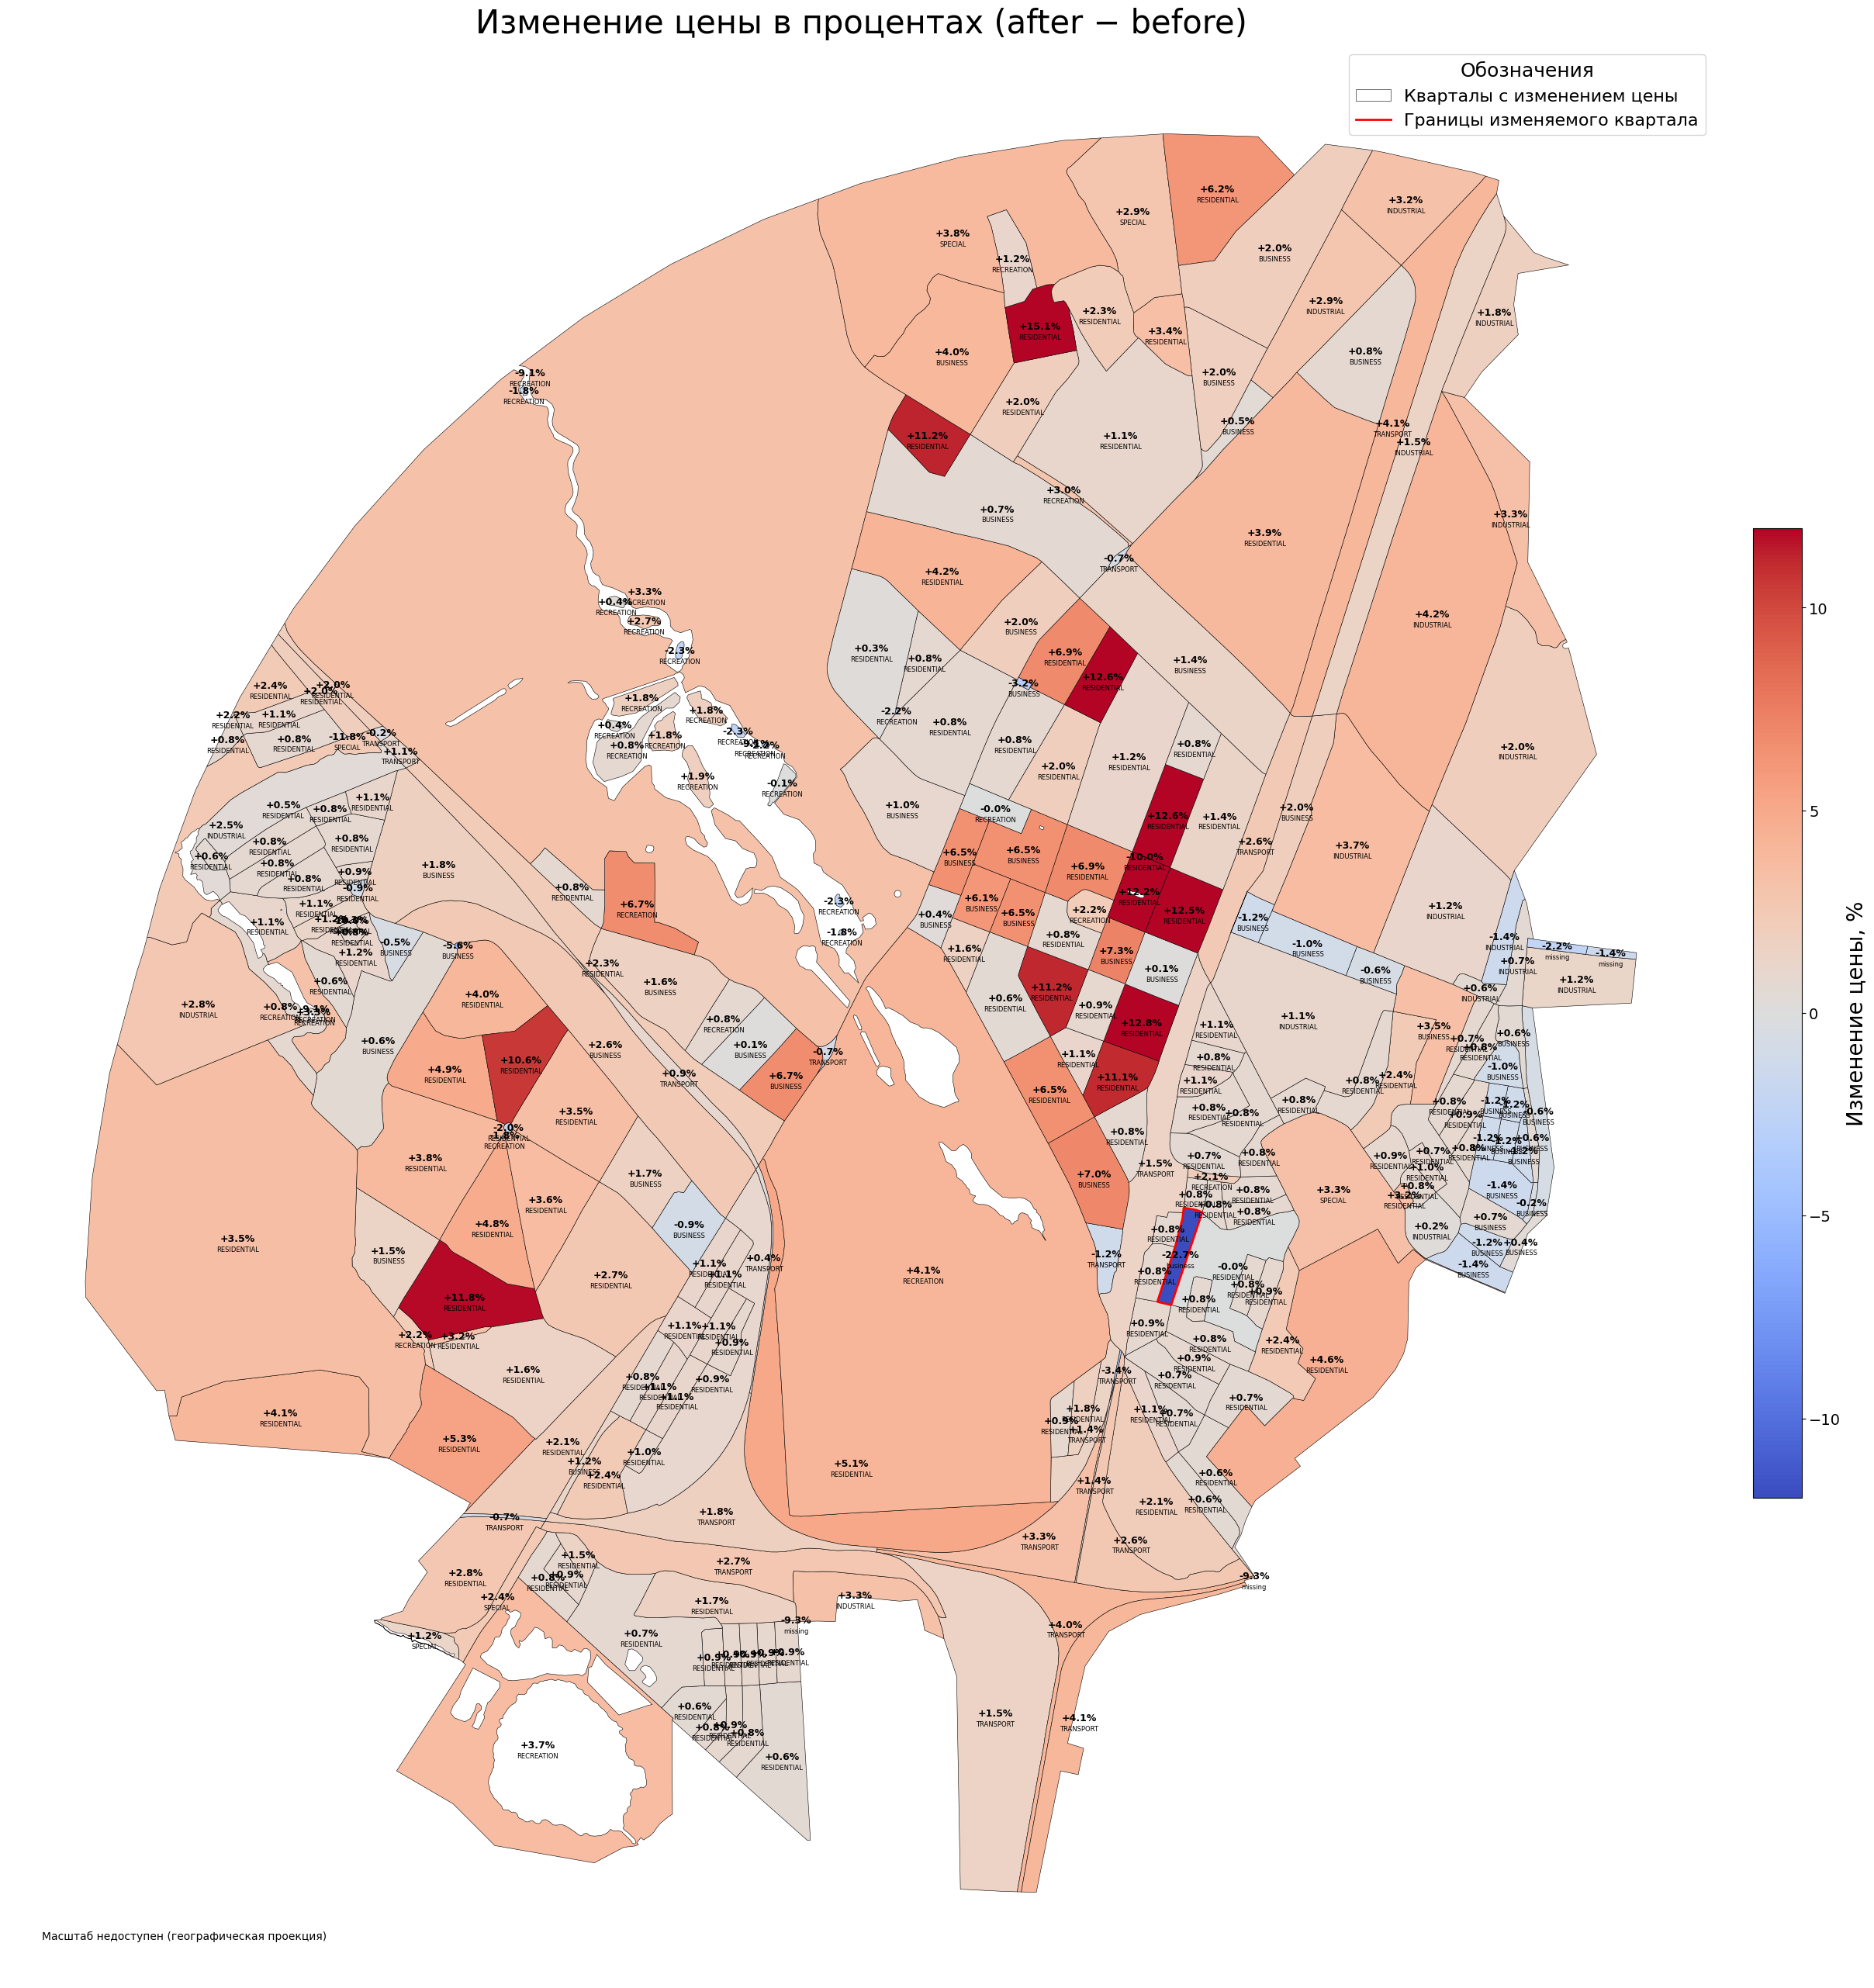


Статистика по кварталам в контексте (|Δ₽| > 1e-09):

Изменяемый квартал:
index | land_use | до (₽) → после (₽) | Δ₽ | Δ%
143 | business | 155 153 751 ₽ → 119 978 993 ₽ | -35 174 758 ₽ | -22.7%

Кварталы в границах проекта:
Нет кварталов проекта с изменениями выше порога.

Кварталы в контексте:
index | land_use | до (₽) → после (₽) | Δ₽ | Δ%
311 | RESIDENTIAL | 568 220 429 ₽ → 571 575 130 ₽ | +3 354 701 ₽ | +0.6%
248 | TRANSPORT | 470 108 239 ₽ → 477 314 264 ₽ | +7 206 026 ₽ | +1.5%
298 | TRANSPORT | 83 519 164 ₽ → 86 889 749 ₽ | +3 370 586 ₽ | +4.0%
115 | RESIDENTIAL | 127 433 496 ₽ → 128 581 294 ₽ | +1 147 798 ₽ | +0.9%
317 | RESIDENTIAL | 155 658 890 ₽ → 157 024 361 ₽ | +1 365 471 ₽ | +0.9%
312 | missing | 14 703 ₽ → 13 339 ₽ | -1 364 ₽ | -9.3%
318 | INDUSTRIAL | 279 176 632 ₽ → 288 297 221 ₽ | +9 120 589 ₽ | +3.3%
225 | TRANSPORT | 231 854 941 ₽ → 239 586 683 ₽ | +7 731 742 ₽ | +3.3%
299 | TRANSPORT | 3 524 255 ₽ → 3 574 682 ₽ | +50 427 ₽ | +1.4%
5 | TRANSPORT | 134 048 439 ₽ → 135

In [ ]:
from urbanomy.methods.land_value_modeling import (
    ScenarioTEPModifier,
    plot_scenario_impact,
    transfer_baseline_prices,
)

blocks_before = basline_blocks.copy()
changes = {
    # Структура использования территории — бизнес-центр
    "land_use": "LandUse.BUSINESS",
    "residential": 0.0,
    "business": 1.0,
    "recreation": 0.0,
    "industrial": 0.0,
    "transport": 0.0,
    "special": 0.0,
    "agriculture": 0.0,
    "share": 1.0,

    "footprint_area": 56198.3860228,    # ≈ 70% от site_area
    "build_floor_area": 449587.0881824, # FSI ≈ 5.6
    "living_area": 0.0,                 # жилья нет
    "non_living_area": 449587.0881824,  # вся площадь – офисы/сервисы
    "population": 0,                    # постоянных жителей нет (только работники)

    # Плотностные индикаторы
    "fsi": 5.6,                         # build_floor_area / site_area
    "gsi": 0.7,                         # footprint_area / site_area
    "l": 8.0,                           # build_floor_area / footprint_area (этажность)
                  # build_floor_area / footprint_area (этажность)

    # Морфотип – деловой центр средней этажности
    "morphotype": "low-rise non-residential",

}

target_idx = 143

modifier = ScenarioTEPModifier(blocks_before)
blocks_after = modifier.apply(target_idx, changes)

# 1) Предсказание стоимости до/после
before_estimator = LandPriceEstimator(model=model, blocks=blocks_before)
after_estimator = LandPriceEstimator(model=model, blocks=blocks_after)

blocks_before_pred = before_estimator.predict()

blocks_before_pred["land_value_per_100m2"] = blocks_before_pred["land_value"] / blocks_before_pred["site_area"] * 100

# # 2) Заменяем inf на NaN
# blocks_before_pred["land_value_per_100m2"] = blocks_before_pred["land_value_per_100m2"].replace([np.inf, -np.inf], np.nan)

# # 3) Удаляем выбросы: оставляем данные до 99-го перцентиля
# p99 = blocks_before_pred["land_value_per_100m2"].quantile(0.99)
# blocks_before_pred = blocks_before_pred[blocks_before_pred["land_value_per_100m2"] <= p99].copy()


blocks_after_pred = after_estimator.predict()

blocks_after_pred["land_value_per_100m2"] = blocks_after_pred["land_value"] / blocks_after_pred["site_area"] * 100

# # 2) Заменяем inf на NaN
# blocks_after_pred["land_value_per_100m2"] = blocks_after_pred["land_value_per_100m2"].replace([np.inf, -np.inf], np.nan)

# # 3) Удаляем выбросы: оставляем данные до 99-го перцентиля
# p99 = blocks_after_pred["land_value_per_100m2"].quantile(0.99)
# blocks_after_pred = blocks_after_pred[blocks_after_pred["land_value_per_100m2"] <= p99].copy()


blocks_full_value = transfer_baseline_prices(
    after_blocks=blocks_after_pred,
    before_blocks=blocks_before_pred,
    scenario_mode=False,
)

blocks_full_value = blocks_full_value.replace([np.inf, -np.inf], np.nan)
blocks_full_value = blocks_full_value.fillna(0)

# 3) Только визуализация и статистика по процентным изменениям
scenario_result = plot_scenario_impact(
    blocks=blocks_full_value,
    target_idx=target_idx,          
    target_id_column="id",   # если колонка называется иначе — укажи здесь
    figsize=(25, 35),
)

In [ ]:
# blocks_full_value.to_file('./data/test/gatchina_BUSINESS.geojson', driver='GeoJSON')

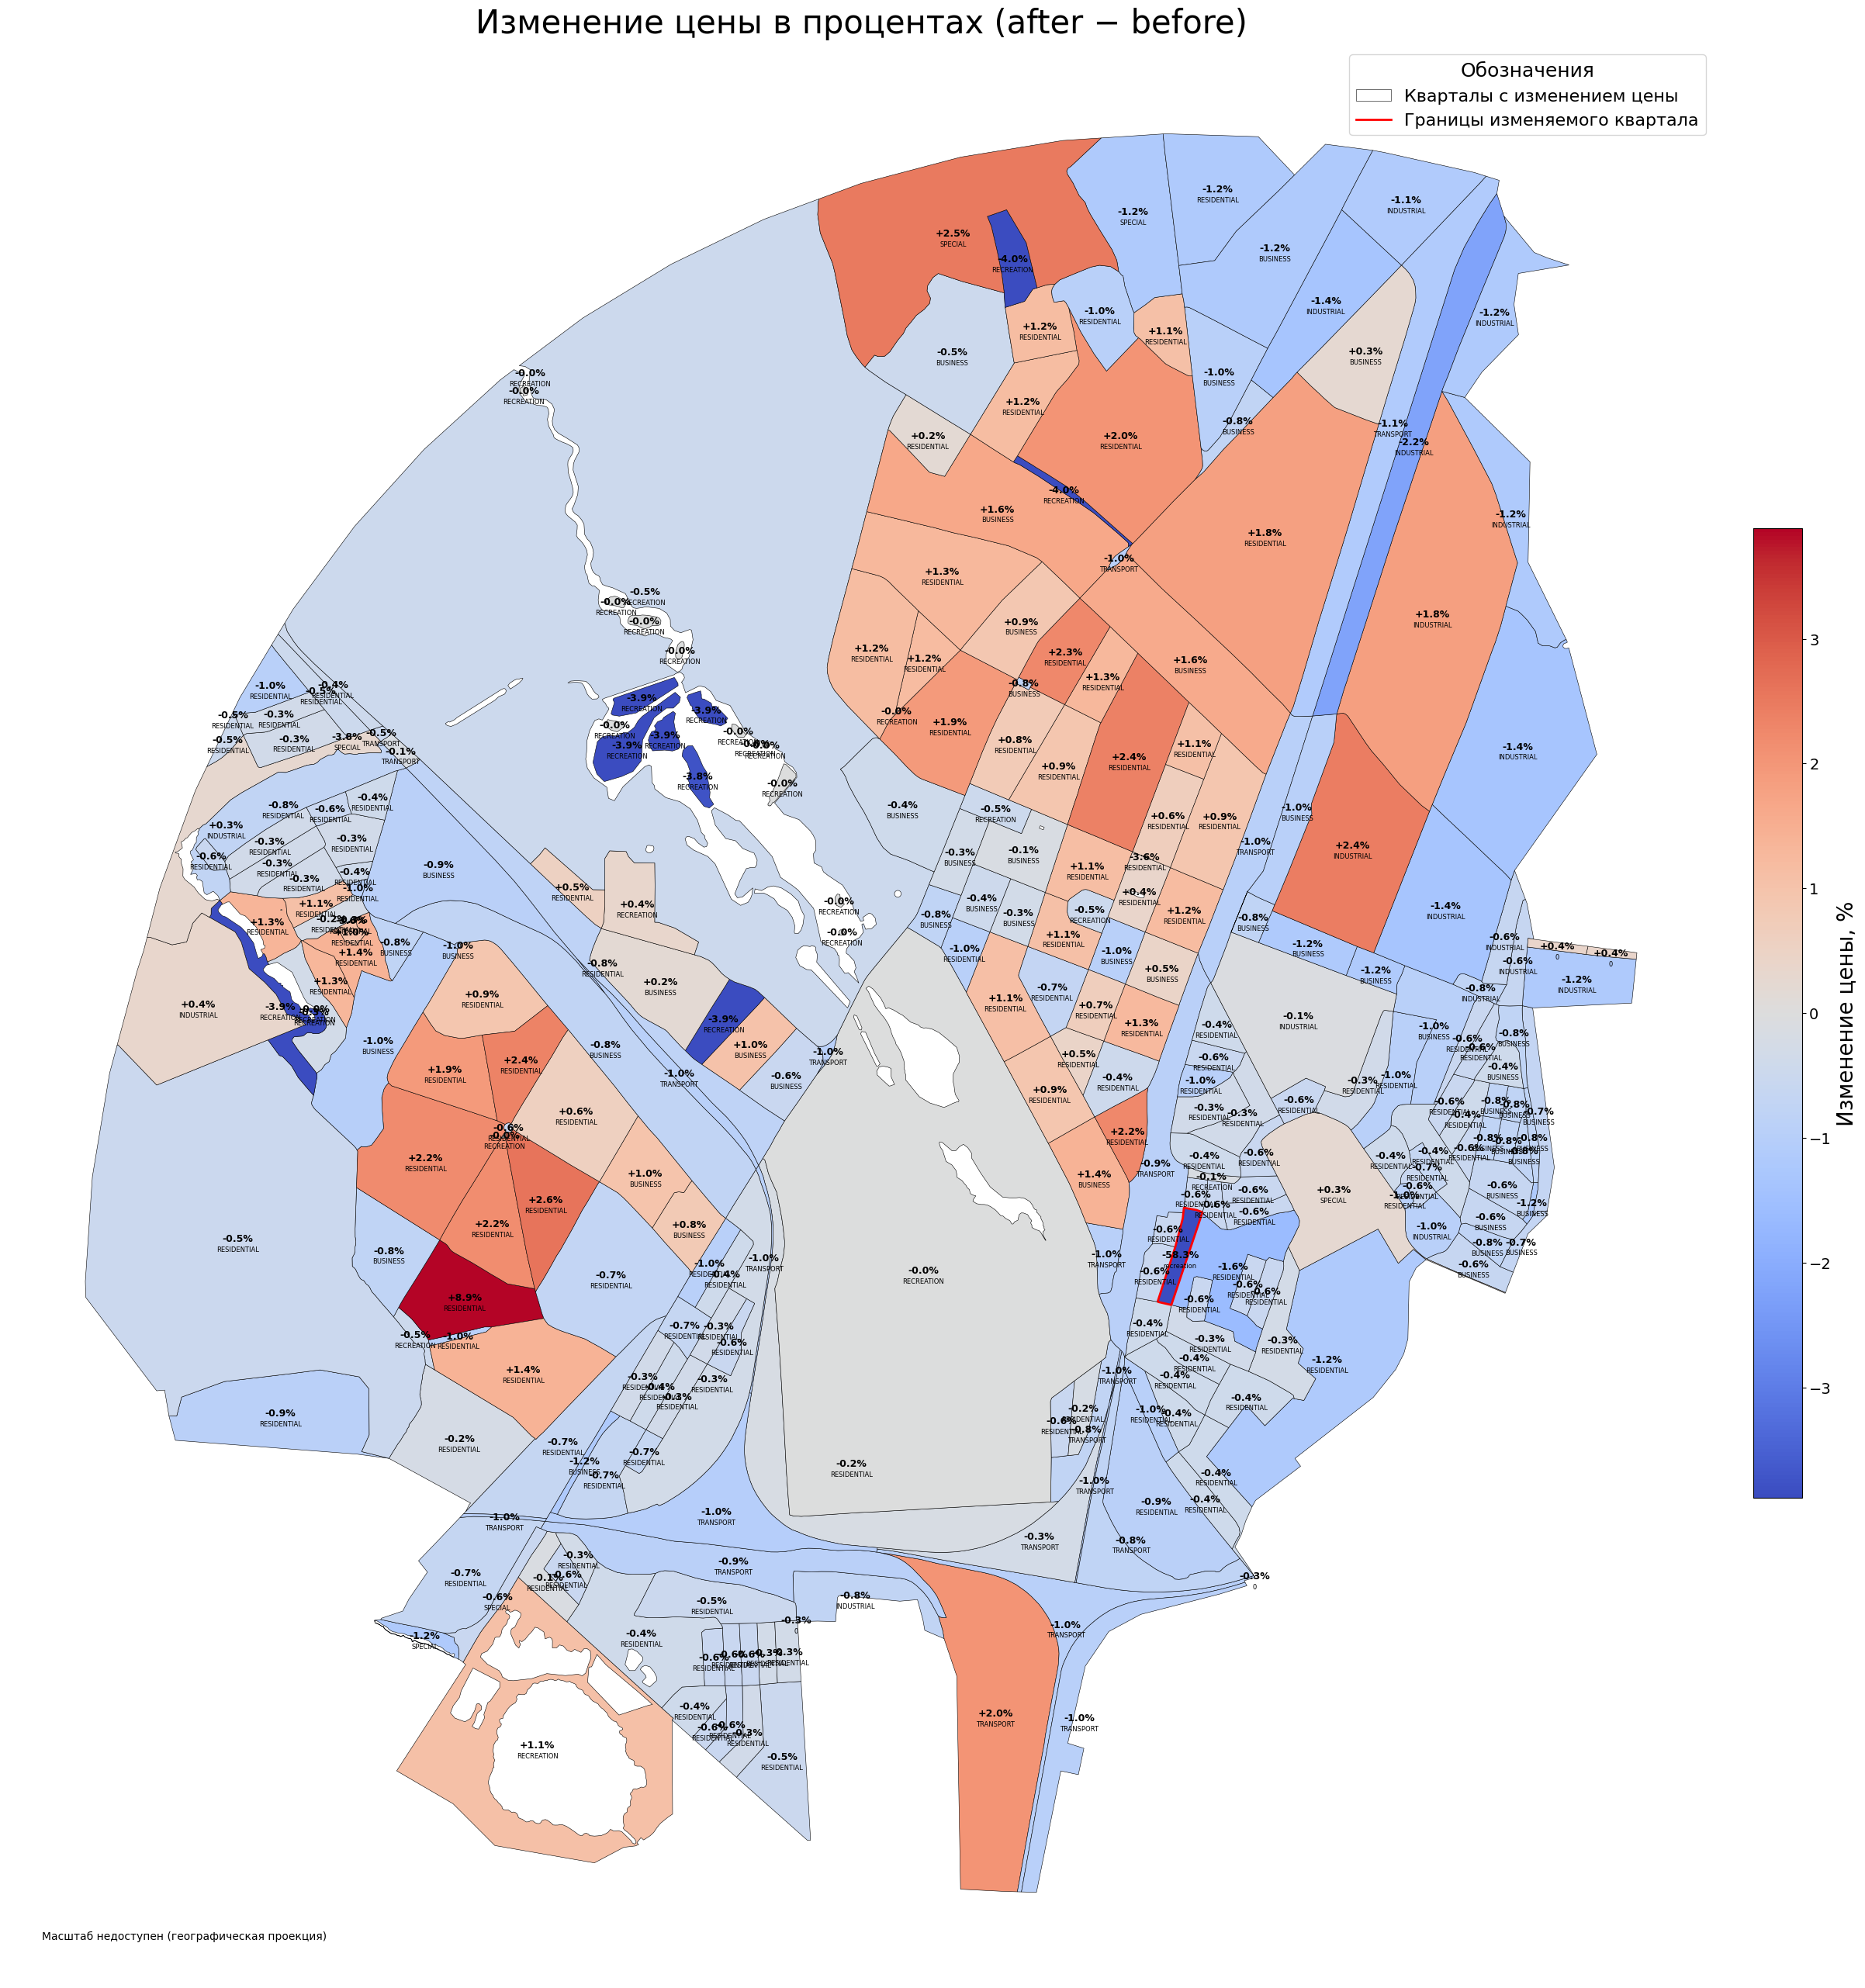


Статистика по кварталам в контексте (|Δ₽| > 1e-09):

Изменяемый квартал:
index | land_use | до (₽) → после (₽) | Δ₽ | Δ%
143 | recreation | 155 153 751 ₽ → 64 642 868 ₽ | -90 510 883 ₽ | -58.3%

Кварталы в границах проекта:
Нет кварталов проекта с изменениями выше порога.

Кварталы в контексте:
index | land_use | до (₽) → после (₽) | Δ₽ | Δ%
311 | RESIDENTIAL | 568 220 429 ₽ → 565 373 988 ₽ | -2 846 441 ₽ | -0.5%
248 | TRANSPORT | 470 108 239 ₽ → 479 740 238 ₽ | +9 631 999 ₽ | +2.0%
298 | TRANSPORT | 83 519 164 ₽ → 82 719 522 ₽ | -799 642 ₽ | -1.0%
115 | RESIDENTIAL | 127 433 496 ₽ → 127 018 433 ₽ | -415 063 ₽ | -0.3%
317 | RESIDENTIAL | 155 658 890 ₽ → 155 151 894 ₽ | -506 996 ₽ | -0.3%
312 | 0 | 14 703 ₽ → 14 664 ₽ | -39 ₽ | -0.3%
318 | INDUSTRIAL | 279 176 632 ₽ → 277 082 332 ₽ | -2 094 300 ₽ | -0.8%
225 | TRANSPORT | 231 854 941 ₽ → 231 170 428 ₽ | -684 513 ₽ | -0.3%
299 | TRANSPORT | 3 524 255 ₽ → 3 490 513 ₽ | -33 742 ₽ | -1.0%
5 | TRANSPORT | 134 048 439 ₽ → 133 042 847 ₽ | -1 

In [54]:
from urbanomy.methods.land_value_modeling import (
    ScenarioTEPModifier,
    plot_scenario_impact,
)

blocks_before = basline_blocks.copy()
changes = {
    # Структура использования территории — парк с отдельным зданием
    "land_use": "LandUse.RECREATION",
    "residential": 0.0,
    "business": 0.1,     # небольшое здание с функцией сервиса/кафе
    "recreation": 0.9,   # основная часть участка – парк
    "industrial": 0.0,
    "transport": 0.0,
    "special": 0.0,
    "agriculture": 0.0,
    "share": 0.9,        # доля доминирующего recreational-использования

    "footprint_area": 6000,   # ≈ 5% от site_area
    "build_floor_area": 12000, # FSI ≈ 0.1
    "living_area": 0.0,               # в парке жилья нет
    "non_living_area": 12000,  # всё здание – нежилая площадь
    "population": 0,                  # постоянных жителей нет

    # Плотностные индикаторы (согласованы с площадями)
    "fsi": 0.1,                       # build_floor_area / site_area
    "gsi": 0.05,                      # footprint_area / site_area
    "l": 2.0,                         # build_floor_area / footprint_area (этажность)

    # Морфотип – парк с низкой застройкой
    "morphotype": "low-rise non-residential",
}

target_idx = 143

modifier = ScenarioTEPModifier(blocks_before)
blocks_after = modifier.apply(target_idx, changes)

# 1) Предсказание стоимости до/после
before_estimator = LandPriceEstimator(model=model, blocks=blocks_before)
after_estimator = LandPriceEstimator(model=model, blocks=blocks_after)

blocks_before_pred = before_estimator.predict()

blocks_before_pred["land_value_per_100m2"] = blocks_before_pred["land_value"] / blocks_before_pred["site_area"] * 100

# # 2) Заменяем inf на NaN
# blocks_before_pred["land_value_per_100m2"] = blocks_before_pred["land_value_per_100m2"].replace([np.inf, -np.inf], np.nan)

# # 3) Удаляем выбросы: оставляем данные до 99-го перцентиля
# p99 = blocks_before_pred["land_value_per_100m2"].quantile(0.99)
# blocks_before_pred = blocks_before_pred[blocks_before_pred["land_value_per_100m2"] <= p99].copy()


blocks_after_pred = after_estimator.predict()

blocks_after_pred["land_value_per_100m2"] = blocks_after_pred["land_value"] / blocks_after_pred["site_area"] * 100

# # 2) Заменяем inf на NaN
# blocks_after_pred["land_value_per_100m2"] = blocks_after_pred["land_value_per_100m2"].replace([np.inf, -np.inf], np.nan)

# # 3) Удаляем выбросы: оставляем данные до 99-го перцентиля
# p99 = blocks_after_pred["land_value_per_100m2"].quantile(0.99)
# blocks_after_pred = blocks_after_pred[blocks_after_pred["land_value_per_100m2"] <= p99].copy()


blocks_full_value = transfer_baseline_prices(
    after_blocks=blocks_after_pred,
    before_blocks=blocks_before_pred,
    scenario_mode=False,
)

blocks_full_value = blocks_full_value.replace([np.inf, -np.inf], np.nan)
blocks_full_value = blocks_full_value.fillna(0)

# 3) Только визуализация и статистика по процентным изменениям
scenario_result = plot_scenario_impact(
    blocks=blocks_full_value,
    target_idx=target_idx,          
    target_id_column="id",   # если колонка называется иначе — укажи здесь
    figsize=(25, 35),
)

In [ ]:
# blocks_full_value.to_file('./data/test/gatchina_RECREATION.geojson', driver='GeoJSON')

# **Инвестиционная** привлекактельтность 

In [40]:
blocks_after = blocks_full_value.copy()
blocks_after["is_project"] = False
blocks_after.loc[blocks_after["id"] == target_idx, "is_project"] = True


In [41]:
from blocksnet.enums import LandUse

benchmarks_demo = {
    LandUse.RESIDENTIAL: {
        "cost_build": 70_000,       # руб/м2 (жильё, СПб/ЛО)
        "price_sale": 160_000,      # руб/м2 (средний класс)
        "construction_years": 3,
        "sale_years": 4,
        "opex_rate": 900,           # эксплуатация жилого фонда
    },
    LandUse.BUSINESS: {
        "cost_build": 85_000,       # офисно-деловая застройка
        "rent_annual": 28_000,      # руб/м2/год
        "rent_years": 12,
        "construction_years": 4,
        "opex_rate": 1_400,
    },
    LandUse.RECREATION: {
        "cost_build": 40_000,       # парки, культура, спорт
        "rent_annual": 9_500,       # чаще косвенные доходы/аренда
        "rent_years": 15,
        "construction_years": 3,
        "opex_rate": 650,
    },
    LandUse.SPECIAL: {              # образование/медицина, гос объект
        "cost_build": 55_000,
        "rent_annual": 12_500,
        "rent_years": 15,
        "construction_years": 3,
        "opex_rate": 1_700,
    },
    LandUse.INDUSTRIAL: {
        "cost_build": 45_000,       # промка (ангар, лайт-индастри)
        "rent_annual": 15_500,
        "rent_years": 12,
        "construction_years": 3,
        "opex_rate": 750,
    },
    LandUse.AGRICULTURE: {
        "cost_build": 28_000,
        "rent_annual": 7_200,
        "rent_years": 15,
        "construction_years": 3,
        "opex_rate": 350,
    },
    LandUse.TRANSPORT: {
        "cost_build": 30_000,       # склад, логистика, хабы
        "rent_annual": 7_000,
        "rent_years": 15,
        "construction_years": 3,
        "opex_rate": 650,
    },
}

In [42]:
from urbanomy.methods.investment_potential import prepare_investment_input


potential_df = pd.read_csv("./data/land_use_potentials.csv")

investment_input = prepare_investment_input(
    gdf = blocks_after,
    project_potential = potential_df,
)

investment_input.head()

,land_use,land_value,land_value_before,site_area,living_area,non_living_area,build_floor_area,share,spatial_potential
0,LandUse.RECREATION,6.464287e+07,1.551538e+08,80283.408604,0.0,12000.0,12000.0,0.9,0.0


In [43]:
from urbanomy.methods.investment_potential import InvestmentAttractivenessAnalyzer

an = InvestmentAttractivenessAnalyzer(benchmarks=benchmarks_demo)
summary = an.calculate_investment_metrics(investment_input, discount_rate=0.18)
summary

Project totals:
 • Land area:          80,283.41
 • Built area:         12,000.00
 • Land value:         64,642,868.28
 • Construction cost:  480,000,000.00
 • Investment need:    544,642,868.28
 • Spatial potential:  0.00
 • Project NPV:        -128,491,221.78
 • Project IRR:        0.13
 • Project ROI:        4.91
 • Project PP (yrs):   nan
 • Project EI:         0.00
 • Project INV score:  0.00


,land_use,land_area,land_value_before,built_area,land_value,construction_cost,investment_need,NPV,IRR,ROI,PP_years,EI,spatial_potential,INV
0,LandUse.RECREATION,80283.41,1.551538e+08,12000.0,64642868.28,480000000.0,5.446429e+08,-1.284912e+08,0.13,4.91,NaN,0.0,0.0,0.0


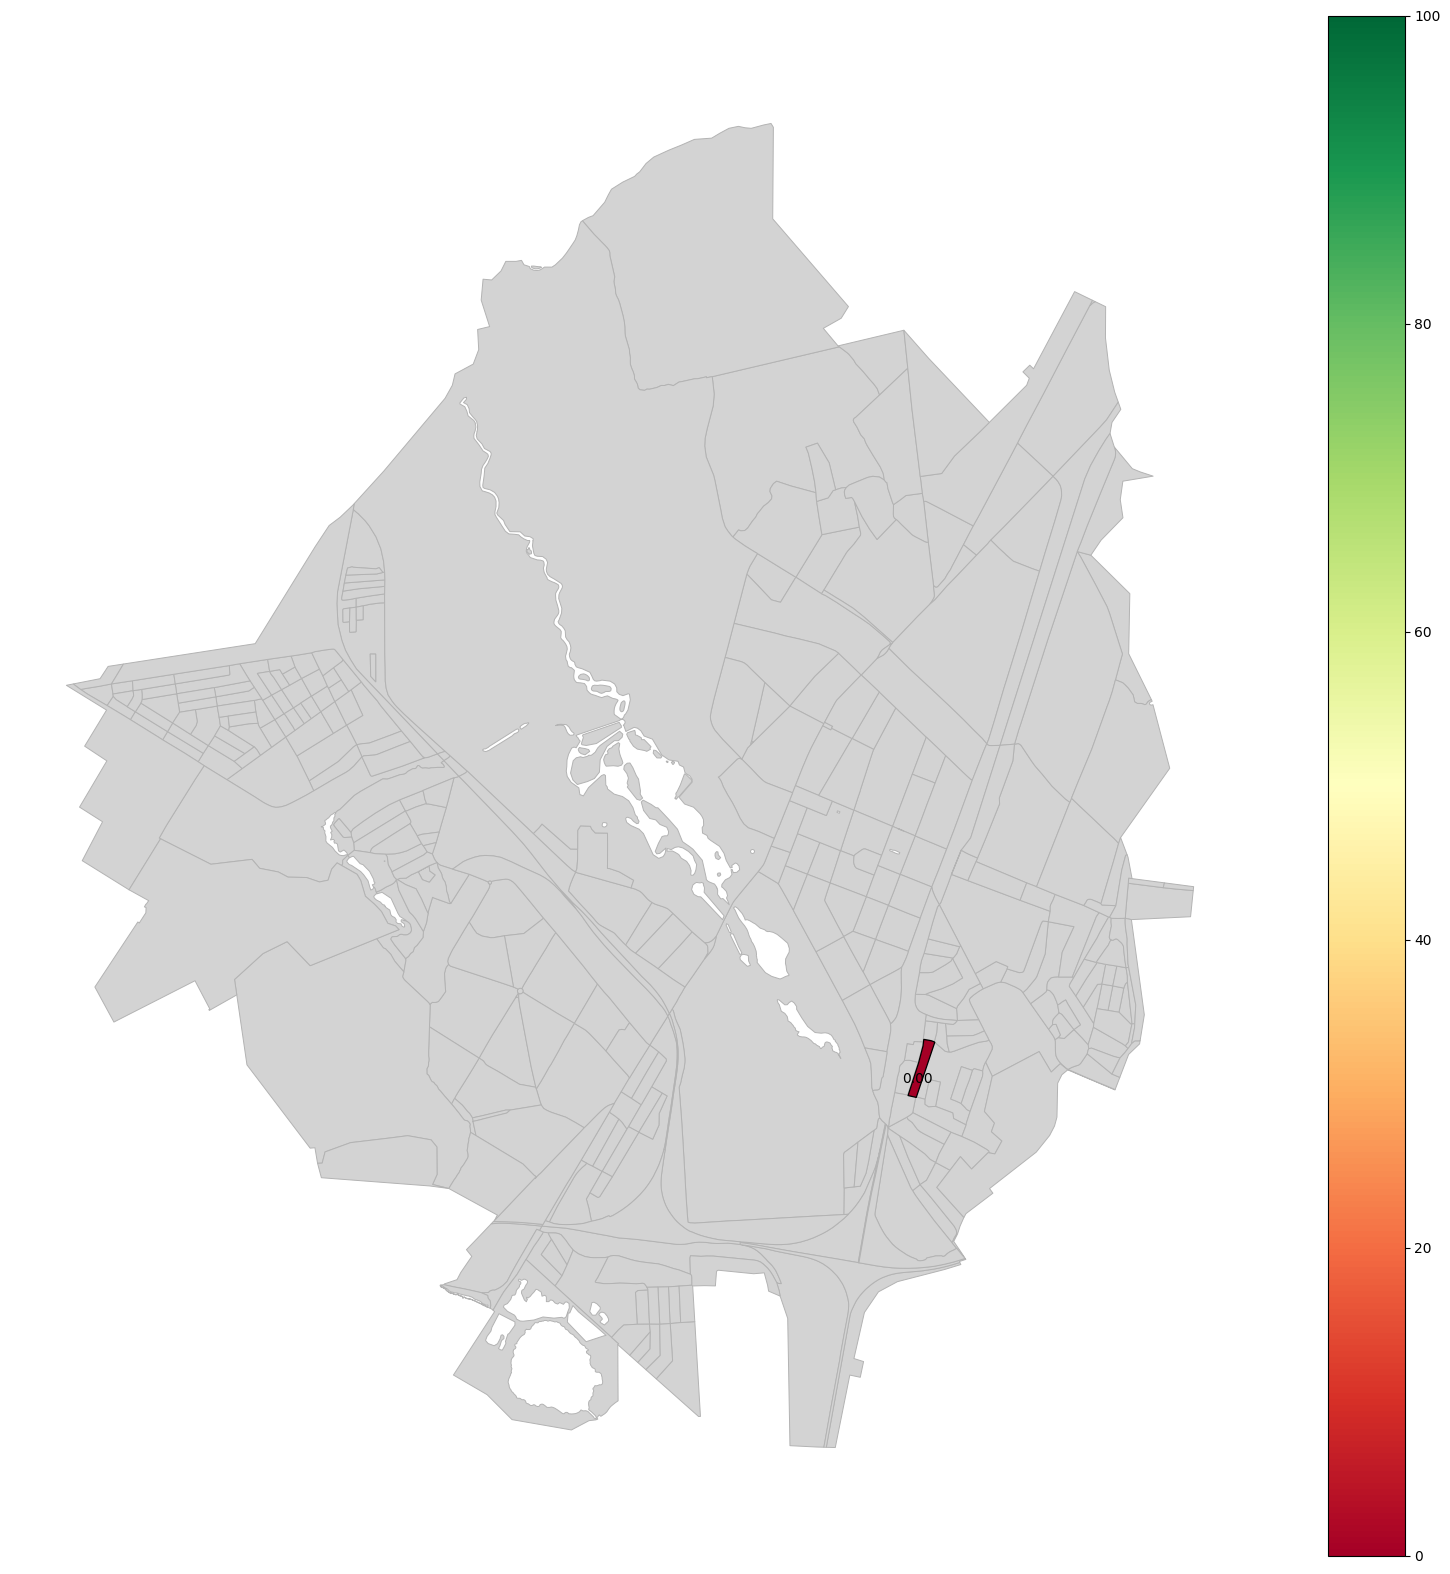

In [44]:
# 1) кладём summary на нужный индекс
summary_idxed = summary.copy()
summary_idxed.index = [target_idx]  # если одна строка; иначе set_index по id

# 2) собираем слой
scn = blocks_after[["geometry"]].join(summary_idxed, how="left")
scn["is_project"] = scn.index == target_idx

column = "INV"
vmin, vmax = 0, 100

fig, ax = plt.subplots(figsize=(20, 20))
scn.loc[~scn["is_project"]].plot(ax=ax, color="lightgrey", edgecolor="0.7", linewidth=0.7)

scn_proj = scn.loc[scn["is_project"]]
if len(scn_proj):
    scn_proj.plot(
        ax=ax,
        column=column,
        cmap="RdYlGn",
        legend=True,
        edgecolor="black",
        linewidth=0.9,
        vmin=vmin,
        vmax=vmax,
    )
    for _, row in scn_proj.dropna(subset=[column]).iterrows():
        x, y = row.geometry.representative_point().coords[0]
        ax.text(x, y, f"{row[column]:.2f}", ha="center", va="center", fontsize=10, color="black")

ax.set_axis_off()
plt.show()

In [45]:
from urbanomy.methods.socio_economic_indicators.sei_calculate import SEREstimator

deafaut_cfg = {
    "population": 300_000,
}

est = SEREstimator(deafaut_cfg) # or use project_cfg
result = est.compute(scn, pretty=True)
result

,indicator,delta_total
0,Объём инвестиций в основной капитал на душу на...,1 600
1,Валовый региональный продукт на душу населения,800
2,Доходы бюджета территории,199 042 337
3,Средний уровень заработной платы,0.0000
4,Износ основного фонда (тыс. руб.),13 680
